# ACM sur les données et CLustering sur l'ACM

je reporend ici le fichier ACM en python et on va ajouter du clustering sur cet ACM

In [3]:
import importlib
import subprocess
import sys
from pathlib import Path
import os

# Installation minimale du package de CA/MCA si besoin.
for pkg in ["prince"]:
    try:
        importlib.import_module(pkg)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", pkg])

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

'/home/gugubre/Projet_analyse_de_donnees_vf/An2DO_4A/analyses/.mplconfig'

## Packages et configuration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display
import prince

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

## Chargement des données

In [5]:
DATA_PATH = Path("../data/raw/Parcoursup.csv")
df_raw = pd.read_csv(DATA_PATH, sep=";")

print(f"Chemin : {DATA_PATH.resolve()}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Chemin : /home/gugubre/Projet_analyse_de_donnees_vf/An2DO_4A/data/raw/Parcoursup.csv
Dimensions : 14252 lignes x 118 colonnes


,Session,"Statut de l’établissement de la filière de formation (public, privé…)",Code UAI de l'établissement,Établissement,Code départemental de l’établissement,Département de l’établissement,Région de l’établissement,Académie de l’établissement,Commune de l’établissement,Filière de formation,...,tri,cod_aff_form,Concours communs et banque d'épreuves,Lien de la formation sur la plateforme Parcoursup,Taux d’accès,Part des terminales générales qui étaient en position de recevoir une proposition en phase principale,Part des terminales technologiques qui étaient en position de recevoir une proposition en phase principale,Part des terminales professionnelles qui étaient en position de recevoir une proposition en phase principale,etablissement_id_paysage,composante_id_paysage
0,2025,Public,0692185A,INSTITUT DES SCIENCES ET TECHNIQUES DE LA READ...,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 8e Arrondissement,Certificat de capacité d'Orthoptiste,...,3_Autres formations,28087,Aix-Marseille Université - Site de Marseille T...,https://dossierappel.parcoursup.fr/Candidats/p...,13,93,7,1,NaN,NaN
1,2025,Public,0931827F,Université Paris 8,93,Seine-Saint-Denis,Ile-de-France,Créteil,Saint-Denis,Licence - Langues étrangères appliquées - Parc...,...,1_universités,28100,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,98,57,24,19,NaN,NaN
2,2025,Public,0421573G,IFSI du CH de Roanne,42,Loire,Auvergne-Rhône-Alpes,Lyon,Roanne,D.E Infirmier,...,3_Autres formations,28144,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,40,56,37,7,NaN,NaN
3,2025,Public,0691774D,Université Claude Bernard Lyon 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Villeurbanne,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,28178,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,36,99,1,0,NaN,NaN
4,2025,Public,0691774D,Université Claude Bernard Lyon 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Villeurbanne,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,28180,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,20,99,1,0,NaN,NaN


In [6]:
selection_cols = [
    "Statut de l’établissement de la filière de formation (public, privé…)",
    "Sélectivité",
    "Filière de formation très agrégée",
    "Région de l’établissement",
    "Académie de l’établissement",
    "Taux d’accès",
    "Capacité de l’établissement par formation",
    "Effectif total des candidats pour une formation",
    "Effectif total des candidats ayant accepté la proposition de l’établissement (admis)",
    "Dont effectif des candidates admises",
    "Effectif des admis néo bacheliers",
    "Dont effectif des admis boursiers néo bacheliers",
    "Dont effectif des admis néo bacheliers avec mention Assez Bien au bac",
    "Dont effectif des admis néo bacheliers avec mention Bien au bac",
    "Dont effectif des admis néo bacheliers avec mention Très Bien au bac",
    "Dont effectif des admis néo bacheliers avec mention Très Bien avec félicitations au bac",
    "% d’admis néo bacheliers généraux",
    "% d’admis néo bacheliers technologiques",
    "% d’admis néo bacheliers professionnels",
]

selection_summary = []
for col in selection_cols:
    s = df_raw[col]
    miss = (s.isna() | (s.astype(str).str.strip() == "")).mean() * 100
    selection_summary.append(
        {
            "variable": col,
            "type_brut": str(s.dtype),
            "nb_modalites_non_vides": s.dropna().astype(str).replace("", pd.NA).dropna().nunique(),
            "pct_manquants": round(miss, 2),
        }
    )

selection_summary = pd.DataFrame(selection_summary).sort_values(["nb_modalites_non_vides", "pct_manquants"])
display(selection_summary)
print()
print("Aperçu des noms de colonnes :")
print(df_raw.columns.tolist()[:20])

,variable,type_brut,nb_modalites_non_vides,pct_manquants
1,Sélectivité,object,2,0.00
0,Statut de l’établissement de la filière de for...,object,4,0.00
2,Filière de formation très agrégée,object,11,0.00
3,Région de l’établissement,object,18,0.68
4,Académie de l’établissement,object,33,0.00
15,Dont effectif des admis néo bacheliers avec me...,int64,54,0.00
17,% d’admis néo bacheliers technologiques,float64,95,0.00
18,% d’admis néo bacheliers professionnels,float64,97,0.00
16,% d’admis néo bacheliers généraux,float64,100,0.00
5,Taux d’accès,object,101,0.40



Aperçu des noms de colonnes :
['Session', 'Statut de l’établissement de la filière de formation (public, privé…)', "Code UAI de l'établissement", 'Établissement', 'Code départemental de l’établissement', 'Département de l’établissement', 'Région de l’établissement', 'Académie de l’établissement', 'Commune de l’établissement', 'Filière de formation', 'Sélectivité', 'Filière de formation très agrégée', 'Filière de formation détaillée', 'Filière de formation.1', 'Filière de formation détaillée bis', 'Filière de formation très détaillée', 'Coordonnées GPS de la formation', 'Capacité de l’établissement par formation', 'Effectif total des candidats pour une formation', 'Dont effectif des candidates pour une formation']


## Préparation des données

Fait par coco

1. **Nettoyer** les variables qualitatives et numériques utiles.
2. **Regrouper** certaines modalités trop fines quand c'est nécessaire pour garder des cartes lisibles.
3. **Construire** quelques variables qualitatives dérivées pour l'ACM, de façon analogue au passage du TP où l'on transformait les données brutes en tableau qualitatif exploitable.

Le but n'est pas de réinventer la base, mais de la rendre compatible avec une analyse factorielle sur variables qualitatives.

In [7]:
def clean_cat(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().replace({"": pd.NA, "nan": pd.NA, "nd": pd.NA})


def clean_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(clean_cat(series).str.replace(",", ".", regex=False), errors="coerce")


def qcut_label(series: pd.Series, labels) -> pd.Series:
    valid = series.dropna()
    cut = pd.qcut(valid, q=len(labels), labels=labels, duplicates="drop")
    out = pd.Series(pd.NA, index=series.index, dtype="object")
    out.loc[valid.index] = cut.astype(str)
    return out.fillna("Non renseigné")


def eta_squared(groups: pd.Series, values: pd.Series) -> float:
    valid = groups.notna() & values.notna()
    g = groups[valid]
    x = values[valid]
    grand_mean = x.mean()
    ss_total = ((x - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    means = x.groupby(g).mean()
    counts = g.value_counts().reindex(means.index)
    ss_between = (counts * (means - grand_mean) ** 2).sum()
    return ss_between / ss_total


def plot_ca_map(row_coords, col_coords, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    ax.scatter(row_coords[0], row_coords[1], c="#1f77b4", s=60, label="Lignes")
    ax.scatter(col_coords[0], col_coords[1], c="#d62728", marker="^", s=70, label="Colonnes")
    for idx, (x, y) in row_coords[[0, 1]].iterrows():
        ax.text(x, y, str(idx), color="#1f77b4", fontsize=9)
    for idx, (x, y) in col_coords[[0, 1]].iterrows():
        ax.text(x, y, str(idx), color="#d62728", fontsize=9)
    ax.set_xlabel("Axe 1")
    ax.set_ylabel("Axe 2")
    ax.set_title(title)
    ax.legend()
    return ax


def plot_mca_modalities(coords, title, color=None, ax=None, top_n=None):
    coords_plot = coords.copy()
    if top_n is not None and color is not None:
        coords_plot = coords_plot.loc[color.sort_values(ascending=False).head(top_n).index]
        color = color.loc[coords_plot.index]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    if color is None:
        ax.scatter(coords_plot[0], coords_plot[1], s=45, color="#2a9d8f")
    else:
        sc = ax.scatter(coords_plot[0], coords_plot[1], c=color, cmap="viridis", s=45)
        plt.colorbar(sc, ax=ax, label=color.name if color.name else "Valeur")
    for idx, (x, y) in coords_plot[[0, 1]].iterrows():
        ax.text(x, y, idx, fontsize=8)
    ax.set_xlabel("Axe 1")
    ax.set_ylabel("Axe 2")
    ax.set_title(title)
    return ax


analysis = pd.DataFrame({
    "statut_brut": clean_cat(df_raw["Statut de l’établissement de la filière de formation (public, privé…)"]),
    "selectivite": clean_cat(df_raw["Sélectivité"]),
    "filiere_agregee": clean_cat(df_raw["Filière de formation très agrégée"]),
    "region": clean_cat(df_raw["Région de l’établissement"]),
    "academie": clean_cat(df_raw["Académie de l’établissement"]),
    "taux_acces": clean_num(df_raw["Taux d’accès"]),
    "capacite": clean_num(df_raw["Capacité de l’établissement par formation"]),
    "candidats_total": clean_num(df_raw["Effectif total des candidats pour une formation"]),
    "admis_total": clean_num(df_raw["Effectif total des candidats ayant accepté la proposition de l’établissement (admis)"]),
    "admises": clean_num(df_raw["Dont effectif des candidates admises"]),
    "admis_neobac": clean_num(df_raw["Effectif des admis néo bacheliers"]),
    "boursiers_admis": clean_num(df_raw["Dont effectif des admis boursiers néo bacheliers"]),
    "mention_ab": clean_num(df_raw["Dont effectif des admis néo bacheliers avec mention Assez Bien au bac"]),
    "mention_b": clean_num(df_raw["Dont effectif des admis néo bacheliers avec mention Bien au bac"]),
    "mention_tb": clean_num(df_raw["Dont effectif des admis néo bacheliers avec mention Très Bien au bac"]),
    "mention_tbf": clean_num(df_raw["Dont effectif des admis néo bacheliers avec mention Très Bien avec félicitations au bac"]),
    "part_gen": clean_num(df_raw["% d’admis néo bacheliers généraux"]),
    "part_tech": clean_num(df_raw["% d’admis néo bacheliers technologiques"]),
    "part_pro": clean_num(df_raw["% d’admis néo bacheliers professionnels"]),
})

analysis["statut"] = analysis["statut_brut"].replace({
    "Privé enseignement supérieur": "Autre privé",
    "Privé hors contrat": "Autre privé",
})
analysis["pression"] = analysis["candidats_total"] / analysis["capacite"].replace(0, np.nan)
analysis["score_mentions"] = (
    analysis["mention_ab"].fillna(0)
    + 2 * analysis["mention_b"].fillna(0)
    + 3 * analysis["mention_tb"].fillna(0)
    + 4 * analysis["mention_tbf"].fillna(0)
) / analysis["admis_neobac"].replace(0, np.nan)
analysis["pct_boursiers"] = 100 * analysis["boursiers_admis"] / analysis["admis_neobac"].replace(0, np.nan)
analysis["pct_filles"] = 100 * analysis["admises"] / analysis["admis_total"].replace(0, np.nan)
profil_max = analysis[["part_gen", "part_tech", "part_pro"]].max(axis=1)
analysis["profil_admis"] = np.select(
    [
        profil_max.lt(45),
        analysis["part_gen"].ge(analysis["part_tech"]) & analysis["part_gen"].ge(analysis["part_pro"]),
        analysis["part_tech"].ge(analysis["part_gen"]) & analysis["part_tech"].ge(analysis["part_pro"]),
    ],
    ["Profil mixte", "Dominante générale", "Dominante technologique"],
    default="Dominante professionnelle",
)

prep_overview = pd.DataFrame({
    "variable": [
        "statut", "selectivite", "filiere_agregee", "region", "academie", "pression", "taux_acces",
        "score_mentions", "pct_boursiers", "pct_filles", "profil_admis"
    ],
    "nb_non_nuls": [analysis[col].notna().sum() for col in [
        "statut", "selectivite", "filiere_agregee", "region", "academie", "pression", "taux_acces",
        "score_mentions", "pct_boursiers", "pct_filles", "profil_admis"
    ]],
    "nb_modalites_ou_valeurs": [analysis[col].nunique(dropna=True) for col in [
        "statut", "selectivite", "filiere_agregee", "region", "academie", "pression", "taux_acces",
        "score_mentions", "pct_boursiers", "pct_filles", "profil_admis"
    ]]
})

display(prep_overview)

,variable,nb_non_nuls,nb_modalites_ou_valeurs
0,statut,14252,3
1,selectivite,14252,2
2,filiere_agregee,14252,11
3,region,14155,18
4,academie,14252,33
5,pression,14248,8075
6,taux_acces,13076,100
7,score_mentions,13954,2840
8,pct_boursiers,13954,1560
9,pct_filles,14073,2521


## ACM - Analyse des correspondances multiples

On passe maintenant à l'analogue de la seconde partie du TP.

Dans le notebook source, l'ACM sert à étudier un **ensemble de variables qualitatives** décrivant les individus. Ici, les "individus" sont les **formations Parcoursup**, et on cherche à voir si plusieurs dimensions qualitatives dessinent des profils cohérents.

### Choix des variables actives

On retient des variables qualitatives ou discrétisées qui ont un sens métier :
- sélectivité ;
- statut de l'établissement ;
- type de filière ;
- niveau de pression de candidature ;
- niveau d'accès ;
- niveau académique des admis ;
- poids des boursiers parmi les admis ;
- féminisation ;
- profil dominant des admis ;
- taille de la formation.

Comme dans le TP, certaines variables numériques sont donc **transformées en classes** pour devenir exploitables dans une ACM.

In [16]:
mca_base = analysis.loc[(analysis["admis_total"] > 0) & (analysis["admis_neobac"] > 0)].copy()
regions_top6 = mca_base["region"].value_counts(dropna=True).head(6).index
mca_base["region_mca"] = mca_base["region"].where(mca_base["region"].isin(regions_top6), "Autres régions").fillna("Région non renseignée")

mca_df = pd.DataFrame({
    "Sélectivité": mca_base["selectivite"].fillna("Non renseigné"),
    "Statut": mca_base["statut"].fillna("Non renseigné"),
    "Filière": mca_base["filiere_agregee"].fillna("Non renseigné"),
    "Pression": qcut_label(mca_base["pression"], ["Pression faible", "Pression modérée", "Pression forte", "Pression très forte"]),
    "Accès": qcut_label(mca_base["taux_acces"], ["Accès difficile", "Accès intermédiaire bas", "Accès intermédiaire haut", "Accès ouvert"]),
    "Mentions": qcut_label(mca_base["score_mentions"], ["Mentions faibles", "Mentions intermédiaires", "Mentions élevées", "Mentions très élevées"]),
    "Boursiers": qcut_label(mca_base["pct_boursiers"], ["Peu de boursiers", "Boursiers assez peu présents", "Boursiers présents", "Beaucoup de boursiers"]),
    "Féminisation": pd.cut(
        mca_base["pct_filles"],
        bins=[-np.inf, 40, 60, np.inf],
        labels=["Majoritairement masculine", "Mixte", "Majoritairement féminine"],
    ).astype("object").fillna("Non renseigné"),
    "Profil admis": pd.Series(mca_base["profil_admis"], index=mca_base.index).fillna("Non renseigné"),
    "Taille": qcut_label(mca_base["capacite"], ["Petite capacité", "Capacité moyenne basse", "Capacité moyenne haute", "Grande capacité"]),
    "Région": mca_base["region_mca"],
}).astype(str)

active_vars = [
    "Sélectivité", "Statut", "Filière", "Pression", "Accès",
    "Mentions", "Boursiers", "Féminisation", "Profil admis", "Taille"
]
quali_sup_vars = ["Région"]

print(f"Jeu ACM : {mca_df.shape[0]} individus x {mca_df.shape[1]} variables")
display(mca_df.head())

display(pd.DataFrame({
    "role": ["active"] * len(active_vars) + ["qualitative supplémentaire"] * len(quali_sup_vars),
    "variable": active_vars + quali_sup_vars,
}))

Jeu ACM : 13954 individus x 11 variables


,Sélectivité,Statut,Filière,Pression,Accès,Mentions,Boursiers,Féminisation,Profil admis,Taille,Région
0,formation sélective,Public,Autre formation,Pression forte,Accès difficile,Mentions très élevées,Boursiers présents,Majoritairement féminine,Dominante générale,Capacité moyenne haute,Auvergne-Rhône-Alpes
1,formation non sélective,Public,Licence,Pression modérée,Accès ouvert,Mentions faibles,Boursiers assez peu présents,Majoritairement féminine,Profil mixte,Capacité moyenne haute,Ile-de-France
2,formation sélective,Public,IFSI,Pression très forte,Accès intermédiaire bas,Mentions élevées,Boursiers assez peu présents,Majoritairement féminine,Dominante technologique,Grande capacité,Auvergne-Rhône-Alpes
3,formation non sélective,Public,PASS,Pression très forte,Accès intermédiaire bas,Mentions très élevées,Boursiers assez peu présents,Mixte,Dominante générale,Grande capacité,Auvergne-Rhône-Alpes
4,formation non sélective,Public,PASS,Pression très forte,Accès difficile,Mentions très élevées,Boursiers assez peu présents,Majoritairement féminine,Dominante générale,Grande capacité,Auvergne-Rhône-Alpes


,role,variable
0,active,Sélectivité
1,active,Statut
2,active,Filière
3,active,Pression
4,active,Accès
5,active,Mentions
6,active,Boursiers
7,active,Féminisation
8,active,Profil admis
9,active,Taille


### Préparation données ACM



### Sélectivité


,effectif
Sélectivité,
formation sélective,10788
formation non sélective,3166



### Statut


,effectif
Statut,
Public,10999
Privé sous contrat d'association,1873
Autre privé,1082



### Filière


...

,effectif
Féminisation,
Majoritairement féminine,5992
Majoritairement masculine,5122
Mixte,2840



### Profil admis


,effectif
Profil admis,
Dominante générale,7191
Dominante professionnelle,3099
Dominante technologique,2576
Profil mixte,1088



### Taille


,effectif
Taille,
Capacité moyenne basse,3540
Petite capacité,3504
Grande capacité,3478
Capacité moyenne haute,3432


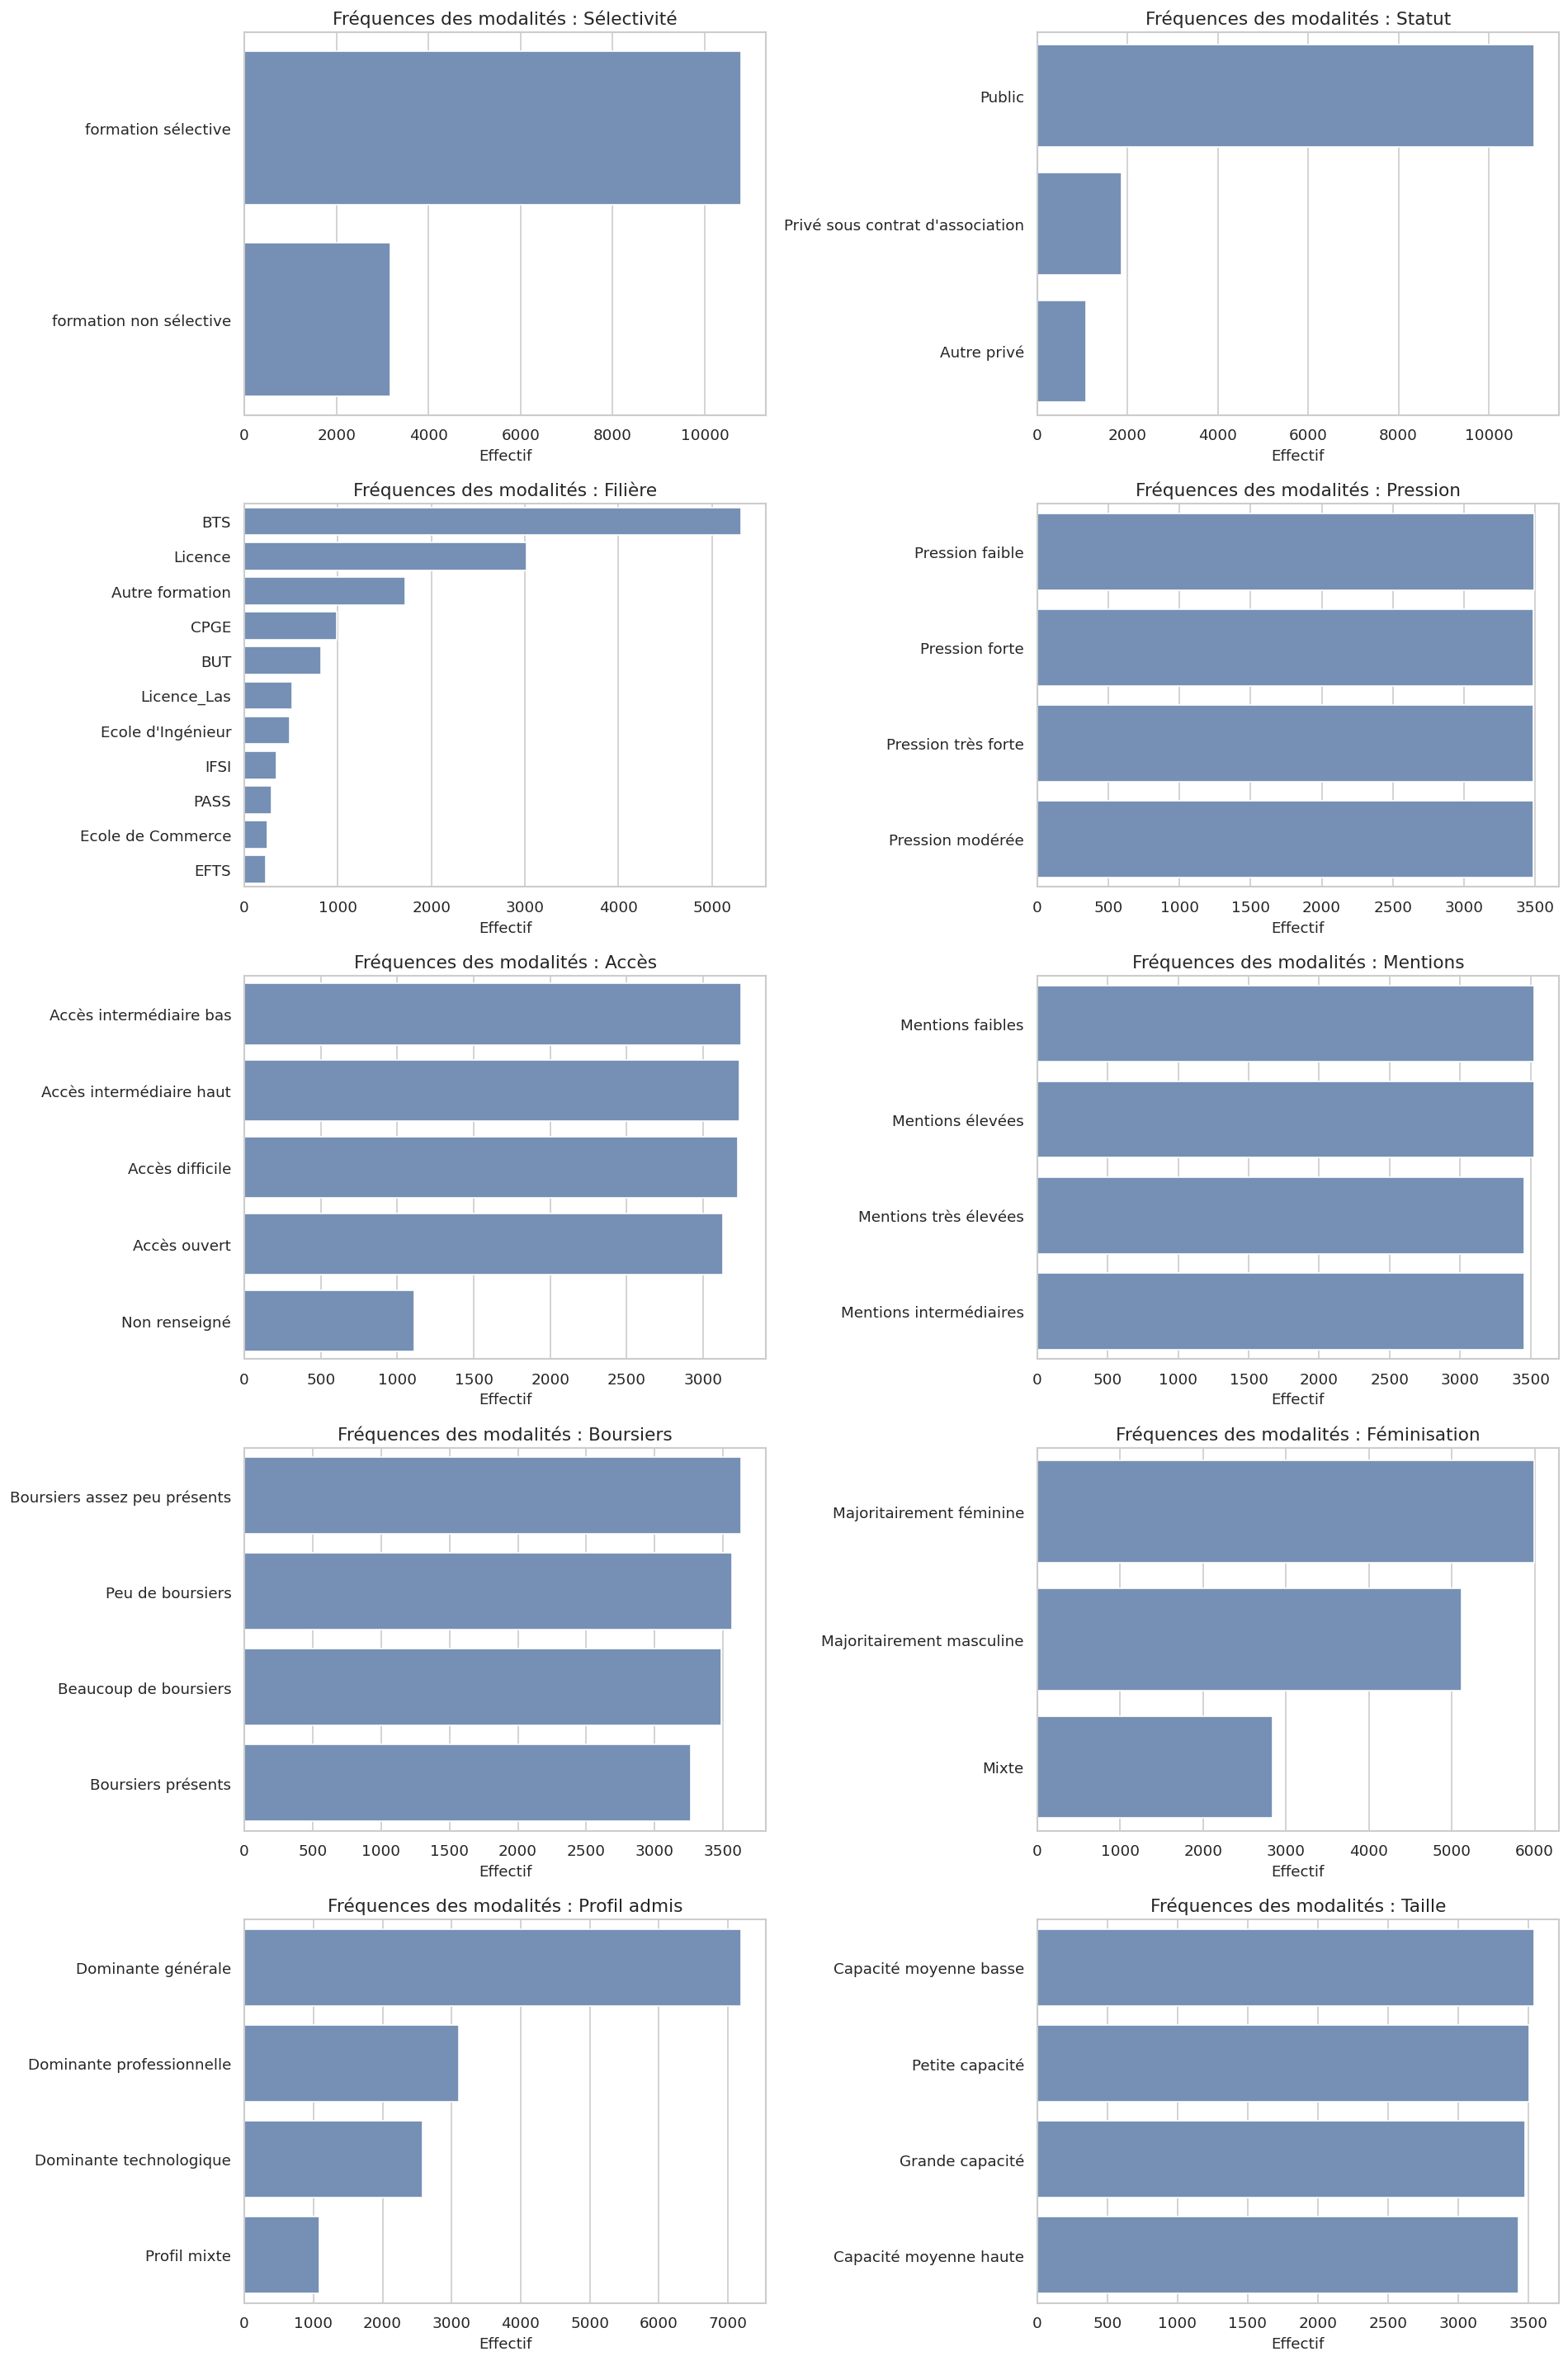

In [17]:
freq_tables = {
    col: mca_df[col].value_counts().rename("effectif")
    for col in active_vars
}

for col in active_vars:
    print()
    print(f"### {col}")
    display(freq_tables[col].to_frame())

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.ravel()
for ax, col in zip(axes, active_vars):
    counts = mca_df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#6c8ebf")
    ax.set_title(f"Fréquences des modalités : {col}")
    ax.set_xlabel("Effectif")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Multiple Correspondence Analysis

On estime maintenant l'ACM sur les **variables actives**, puis on suit la même logique que dans le TP :
- inertie par axe ;
- carte des modalités ;
- qualité de représentation ;
- contributions ;
- lecture des axes.

La région sera utilisée plus loin comme **variable de contexte**, dans l'esprit des éléments supplémentaires de la fin du TP source.

In [18]:
mca = prince.MCA(n_components=5, random_state=42).fit(mca_df[active_vars])
mca_eig = mca.eigenvalues_summary
row_coords_mca = mca.row_coordinates(mca_df[active_vars])
mod_coords = mca.column_coordinates(mca_df[active_vars])
mod_cos2 = mca.column_cosine_similarities(mca_df[active_vars])
ind_cos2 = mca.row_cosine_similarities(mca_df[active_vars])

X = pd.get_dummies(mca_df[active_vars], prefix_sep="__")
mod_masses = X.sum(axis=0) / X.values.sum()
mod_contrib = mod_coords.pow(2).mul(mod_masses, axis=0).div(mca.eigenvalues_, axis=1) * 100

print("Valeurs propres et inertie expliquée :")
display(mca_eig)

Valeurs propres et inertie expliquée :


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.315,9.26%,9.26%
1,0.235,6.91%,16.18%
2,0.204,5.99%,22.16%
3,0.165,4.87%,27.03%
4,0.157,4.61%,31.65%


### Lecture de l'inertie de l'ACM


Les pourcentages d'inertie par axe sont très bas peu de vriables sont très corrélées.

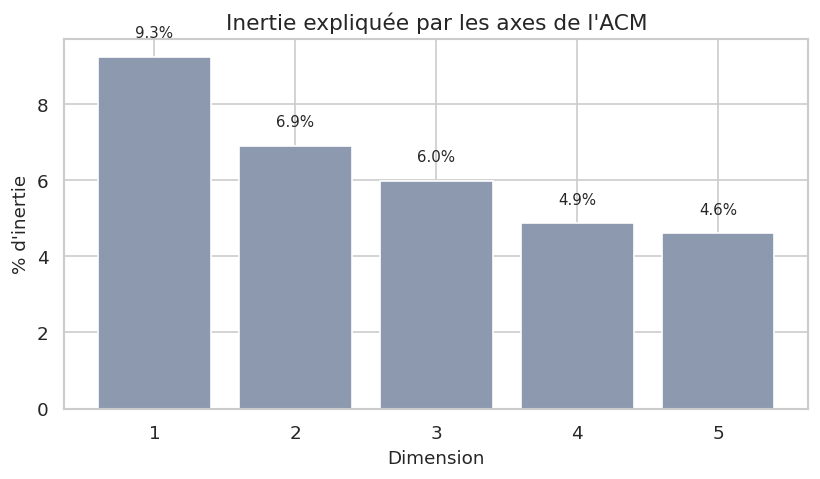

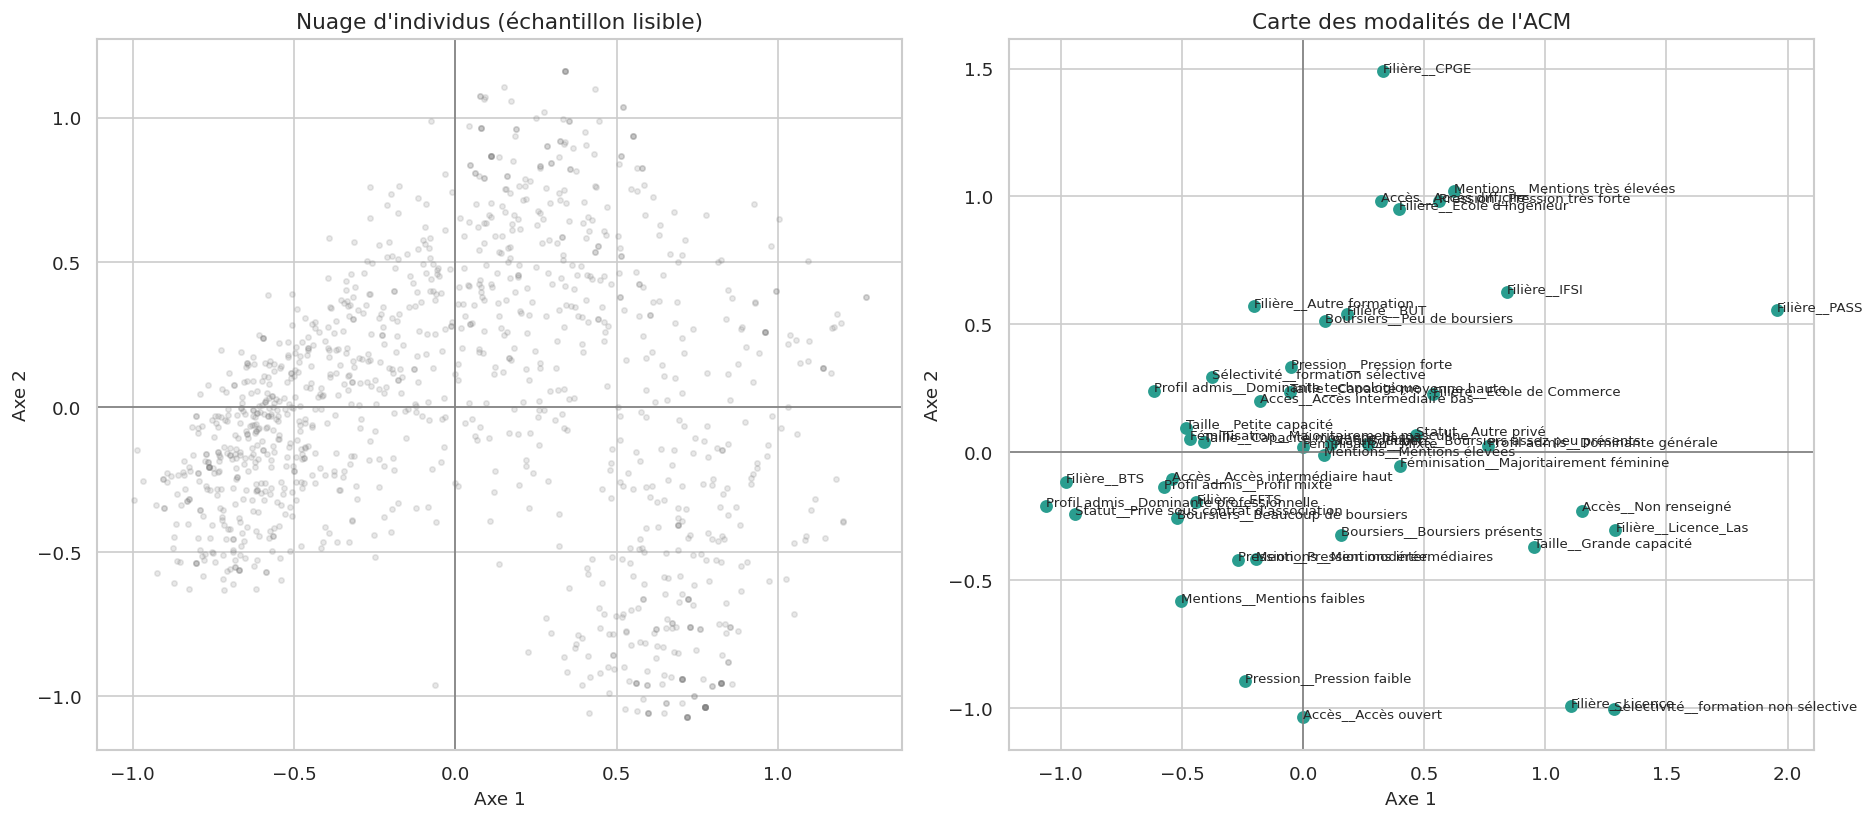

In [19]:
eig_pct_mca = mca.percentage_of_variance_

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(eig_pct_mca) + 1), eig_pct_mca, color="#8d99ae")
ax.set_xlabel("Dimension")
ax.set_ylabel("% d'inertie")
ax.set_title("Inertie expliquée par les axes de l'ACM")
for i, v in enumerate(eig_pct_mca, start=1):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.show()

sample_idx = row_coords_mca.sample(n=min(1200, len(row_coords_mca)), random_state=42).index
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(row_coords_mca.loc[sample_idx, 0], row_coords_mca.loc[sample_idx, 1], s=10, alpha=0.18, color="grey")
axes[0].axhline(0, color="grey", lw=1)
axes[0].axvline(0, color="grey", lw=1)
axes[0].set_title("Nuage d'individus (échantillon lisible)")
axes[0].set_xlabel("Axe 1")
axes[0].set_ylabel("Axe 2")

plot_mca_modalities(mod_coords, "Carte des modalités de l'ACM", ax=axes[1])
plt.tight_layout()
plt.show()

### Que lit-on sur le plan principal ?

La carte des modalités est l'analogue du biplot de l'ACM du TP.

Sur ces données, le plan principal fait apparaître une opposition assez nette entre :
- un pôle où l'on retrouve davantage les **formations non sélectives**, les **Licences**, les **grandes capacités** et les profils à **dominante générale** ;
- un autre pôle où l'on observe plus souvent des **BTS**, des profils à **dominante professionnelle** ou technologique, et des formations plus petites ou plus spécialisées.

L'axe 2 affine ensuite cette lecture en opposant plutôt des formations **très demandées, difficiles d'accès et avec de très bonnes mentions** à des formations **plus ouvertes**, avec une pression plus faible.

### Corrélation des variables avec les axes

Dans le TP, une étape importante consiste à se demander : **quelles variables expliquent le plus chaque axe ?**

En Python, on peut approcher cette idée avec un **eta²** entre chaque variable qualitative et les coordonnées des individus sur les axes 1 et 2. Cela permet de voir quelles variables structurent vraiment le plan principal.

,Axe 1,Axe 2
Filière,0.812798,0.484034
Profil admis,0.647815,0.022313
Sélectivité,0.482253,0.296311
Taille,0.327926,0.050637
Accès,0.204698,0.480032
Mentions,0.171390,0.386447
Féminisation,0.149311,0.002362
Statut,0.146230,0.008967
Pression,0.111625,0.511541
Boursiers,0.094732,0.108202


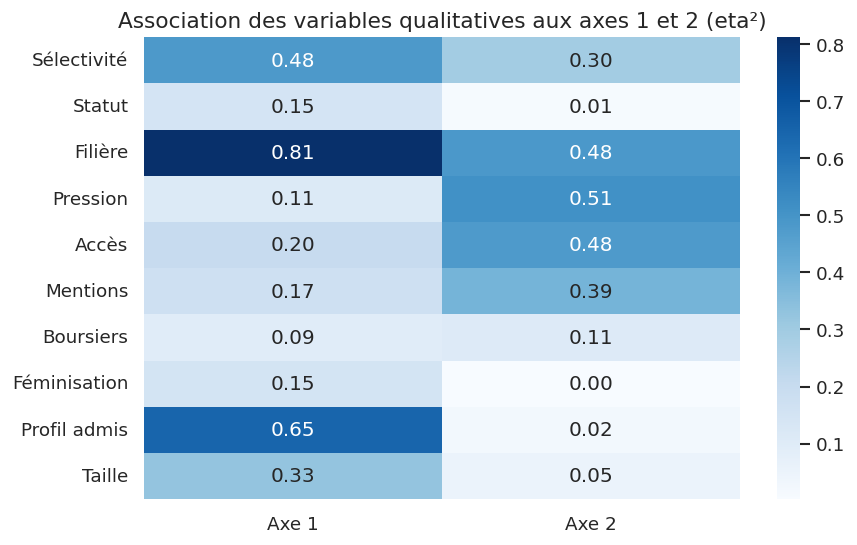

In [20]:
eta2 = pd.DataFrame(
    {
        f"Axe {dim+1}": [eta_squared(mca_df[var], row_coords_mca[dim]) for var in active_vars]
        for dim in range(2)
    },
    index=active_vars,
)

display(eta2.sort_values("Axe 1", ascending=False))

plt.figure(figsize=(8, 5))
sns.heatmap(eta2, annot=True, fmt=".2f", cmap="Blues")
plt.title("Association des variables qualitatives aux axes 1 et 2 (eta²)")
plt.show()

### Lecture de l'association variable-axe

On retrouve ici un résultat très utile pour l'interprétation :

- **Axe 1** est surtout lié à la **filière**, au **profil des admis** et à la **sélectivité** ;
- **Axe 2** est surtout lié à la **pression de candidature**, au **niveau d'accès**, aux **mentions** et, dans une moindre mesure, au type de filière.

Autrement dit :
- l'axe 1 décrit surtout des **profils de formations** ;
- l'axe 2 décrit davantage un **gradient d'ouverture / tension / niveau académique**.

### Qualité de représentation

Comme dans le TP, on vérifie maintenant quelles modalités et quels individus sont bien projetés sur le plan `(1,2)`.

C'est indispensable pour éviter les interprétations trop rapides :
- une modalité avec un `cos2` élevé est bien résumée par les deux premiers axes ;
- une modalité avec un `cos2` faible demande plus de prudence ;
- pour les individus, il est normal qu'ils ne soient pas tous aussi bien représentés.

Modalités les mieux représentées sur le plan (1,2) :


,cos2_plan
Sélectivité__formation sélective,0.778565
Sélectivité__formation non sélective,0.778565
Profil admis__Dominante générale,0.622870
Filière__Licence,0.607067
Filière__BTS,0.595631
Mentions__Mentions très élevées,0.469632
Pression__Pression très forte,0.424908
Taille__Grande capacité,0.347515
Profil admis__Dominante professionnelle,0.335192
Accès__Accès difficile,0.322626


Modalités les moins bien représentées sur le plan (1,2) :


,cos2_plan
Féminisation__Mixte,0.000126
Mentions__Mentions élevées,0.002520
Filière__EFTS,0.003814
Filière__Ecole de Commerce,0.006158
Statut__Autre privé,0.018718
Taille__Capacité moyenne haute,0.018912
Filière__BUT,0.020399
Accès__Accès intermédiaire bas,0.021987
Boursiers__Boursiers assez peu présents,0.026019
Filière__IFSI,0.027832


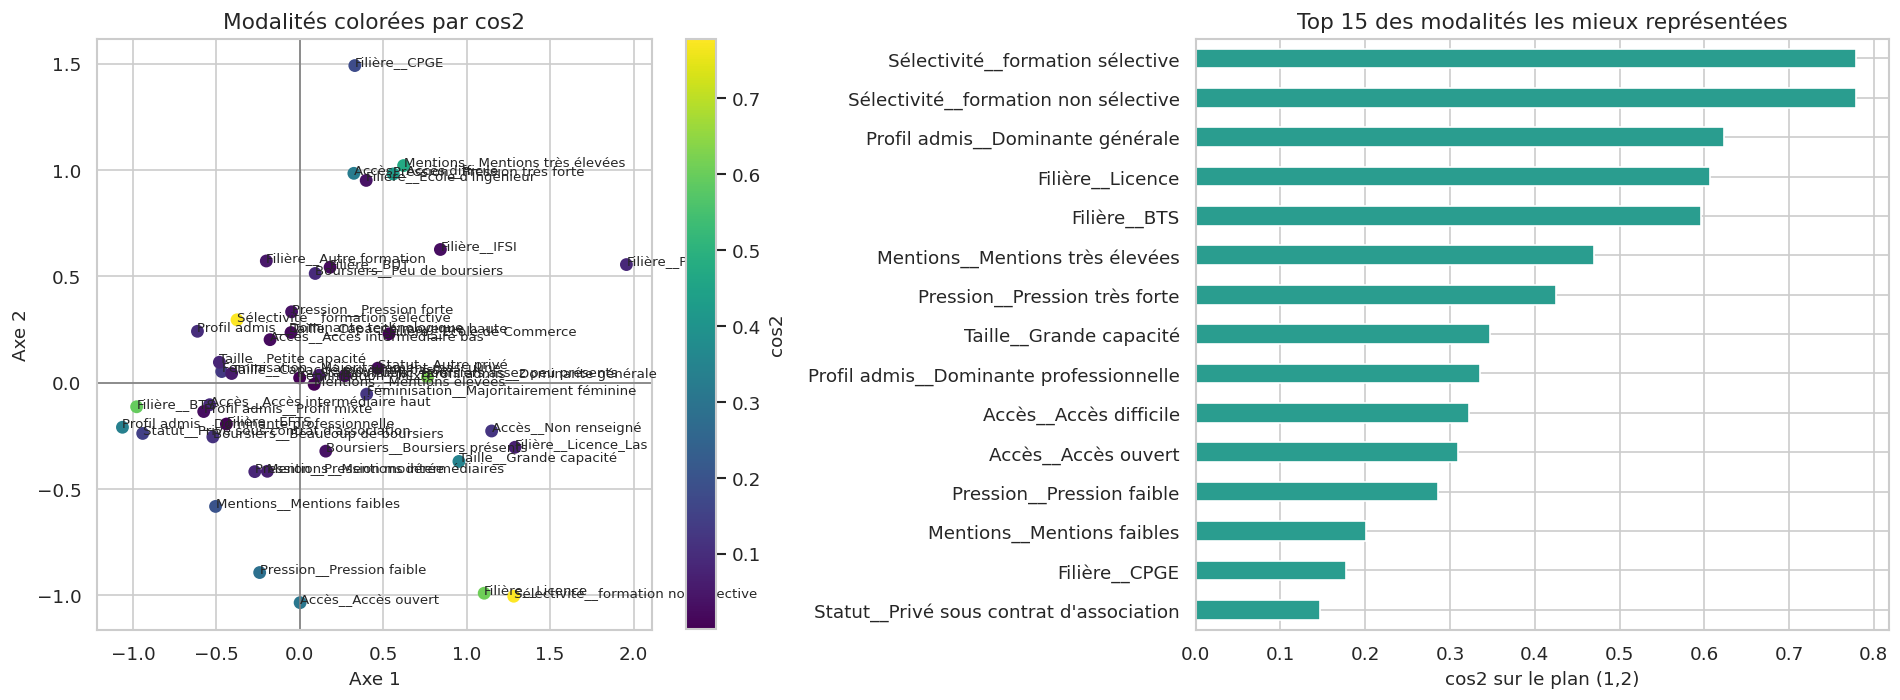

Part des individus ayant un cos2 plan (1,2) >= 0.2 : 0.376
Part des individus ayant un cos2 plan (1,2) >= 0.5 : 0.036


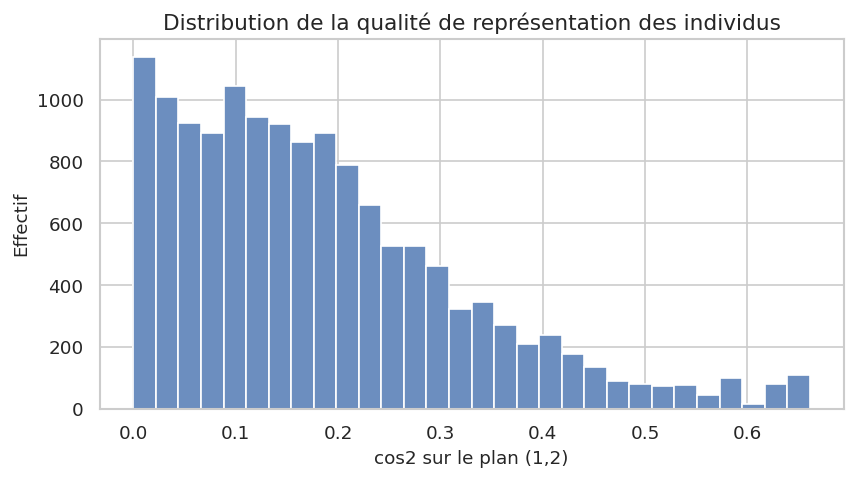

In [21]:
mod_cos2_plane = mod_cos2[0] + mod_cos2[1]
ind_cos2_plane = ind_cos2[0] + ind_cos2[1]

print("Modalités les mieux représentées sur le plan (1,2) :")
display(mod_cos2_plane.sort_values(ascending=False).head(12).to_frame("cos2_plan"))

print("Modalités les moins bien représentées sur le plan (1,2) :")
display(mod_cos2_plane.sort_values().head(12).to_frame("cos2_plan"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_mca_modalities(mod_coords, "Modalités colorées par cos2", color=mod_cos2_plane.rename("cos2"), ax=axes[0])

mod_cos2_plane.sort_values(ascending=False).head(15).sort_values().plot(kind="barh", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Top 15 des modalités les mieux représentées")
axes[1].set_xlabel("cos2 sur le plan (1,2)")

plt.tight_layout()
plt.show()

print(f"Part des individus ayant un cos2 plan (1,2) >= 0.2 : {(ind_cos2_plane >= 0.2).mean():.3f}")
print(f"Part des individus ayant un cos2 plan (1,2) >= 0.5 : {(ind_cos2_plane >= 0.5).mean():.3f}")

plt.figure(figsize=(8, 4))
plt.hist(ind_cos2_plane, bins=30, color="#6c8ebf", edgecolor="white")
plt.title("Distribution de la qualité de représentation des individus")
plt.xlabel("cos2 sur le plan (1,2)")
plt.ylabel("Effectif")
plt.show()

### Lecture de la qualité de représentation en ACM

On retrouve exactement la mise en garde du TP : **toutes les modalités et tous les individus ne sont pas également bien représentés**.

Ici, les modalités liées à la **sélectivité**, aux grandes **filières** (comme BTS ou Licence), aux **mentions très élevées** ou à la **pression très forte** sont globalement mieux projetées sur le plan principal. En revanche, certaines modalités intermédiaires ou plus rares restent plus floues.

Pour les individus, seule une partie des formations est très bien résumée par les deux premiers axes. C'est normal en ACM, et cela invite à une interprétation raisonnable du plan `(1,2)` : utile, mais pas exhaustive.

### Contribution aux dimensions

Comme dans le TP, on termine le cœur de l'ACM par la question : **quelles modalités construisent vraiment les axes ?**

On regarde ici les contributions des modalités aux axes 1 et 2, puis une carte des modalités colorée par leur contribution totale sur le plan principal.

Top 20 des modalités contributives à l'axe 1 :


,contribution_axe1
Sélectivité__formation non sélective,11.840640
Filière__BTS,11.559492
Profil admis__Dominante générale,9.577087
Filière__Licence,8.377581
Profil admis__Dominante professionnelle,7.968917
Taille__Grande capacité,7.195736
Statut__Privé sous contrat d'association,3.779303
Sélectivité__formation sélective,3.474923
Accès__Non renseigné,3.344083
Mentions__Mentions très élevées,3.041292


Top 20 des modalités contributives à l'axe 2 :


,contribution_axe2
Mentions__Mentions très élevées,10.958685
Pression__Pression très forte,10.224031
Accès__Accès ouvert,10.215514
Sélectivité__formation non sélective,9.744667
Accès__Accès difficile,9.518301
Filière__Licence,9.022631
Pression__Pression faible,8.495055
Filière__CPGE,6.676925
Mentions__Mentions faibles,3.645059
Boursiers__Peu de boursiers,2.859831


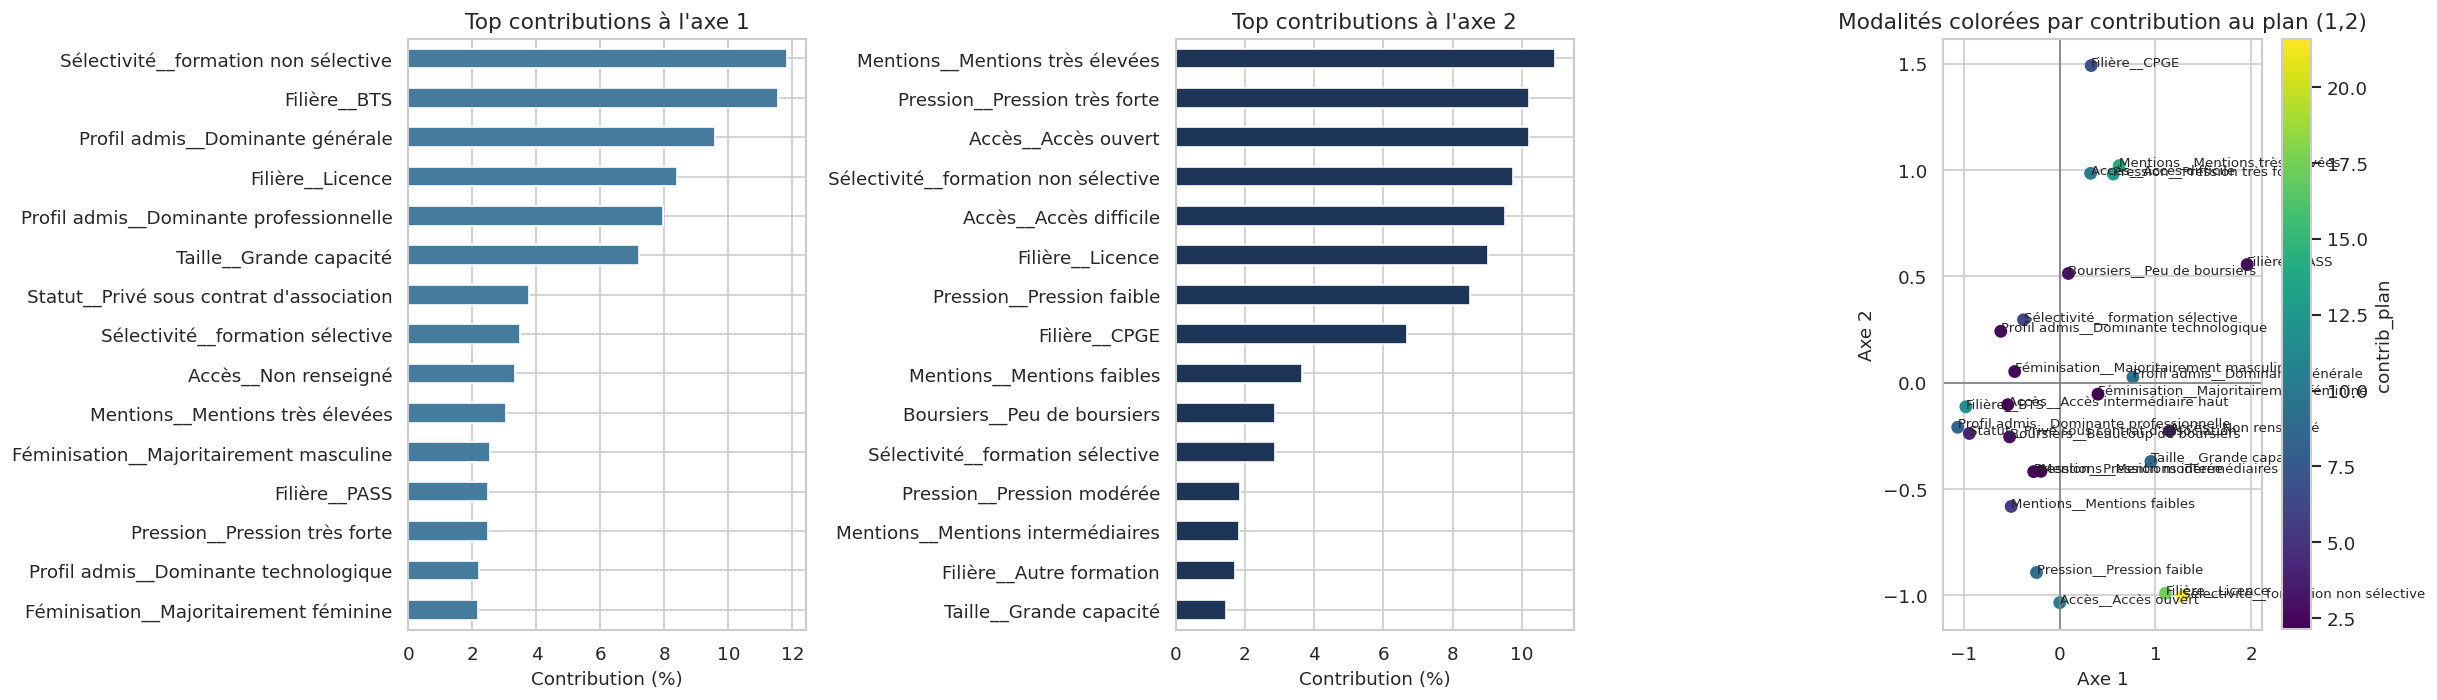

In [22]:
print("Top 20 des modalités contributives à l'axe 1 :")
display(mod_contrib[0].sort_values(ascending=False).head(20).to_frame("contribution_axe1"))

print("Top 20 des modalités contributives à l'axe 2 :")
display(mod_contrib[1].sort_values(ascending=False).head(20).to_frame("contribution_axe2"))

mod_contrib_plane = mod_contrib[0] + mod_contrib[1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
mod_contrib[0].sort_values(ascending=False).head(15).sort_values().plot(kind="barh", ax=axes[0], color="#457b9d")
axes[0].set_title("Top contributions à l'axe 1")
axes[0].set_xlabel("Contribution (%)")

mod_contrib[1].sort_values(ascending=False).head(15).sort_values().plot(kind="barh", ax=axes[1], color="#1d3557")
axes[1].set_title("Top contributions à l'axe 2")
axes[1].set_xlabel("Contribution (%)")

plot_mca_modalities(mod_coords, "Modalités colorées par contribution au plan (1,2)", color=mod_contrib_plane.rename("contrib_plan"), ax=axes[2], top_n=25)

plt.tight_layout()
plt.show()

### Interprétation synthétique de l'ACM

La structure principale qui ressort est la suivante :

- **Axe 1** oppose surtout des formations de type **BTS**, plus souvent associées à une **dominante professionnelle** ou technologique, à des formations comme les **Licences**, **PASS** ou **Licence_LAS**, plus souvent associées à une **dominante générale**, à de **grandes capacités** et à une logique moins sélective.
- **Axe 2** ressemble davantage à un gradient de **tension académique** : d'un côté, des formations avec **pression forte**, **accès difficile** et **mentions très élevées** ; de l'autre, des formations plus **ouvertes**, avec une pression plus faible et un accès plus aisé.

Ce résultat est intéressant, car il montre que l'ACM ne fait pas apparaître seulement des types de filières : elle fait aussi émerger une seconde structuration liée à la **difficulté d'accès** et au **niveau scolaire des admis**.

### Représentation des individus

Dans le TP, la lecture des individus venait compléter celle des modalités. Avec plus de 13 000 formations, il faut rester lisible : on affiche donc un **échantillon visuel** d'individus, coloré par quelques variables parlantes.

Le but n'est pas d'interpréter chaque point, mais de vérifier si des **nuages distincts** apparaissent selon la sélectivité ou le type de filière.

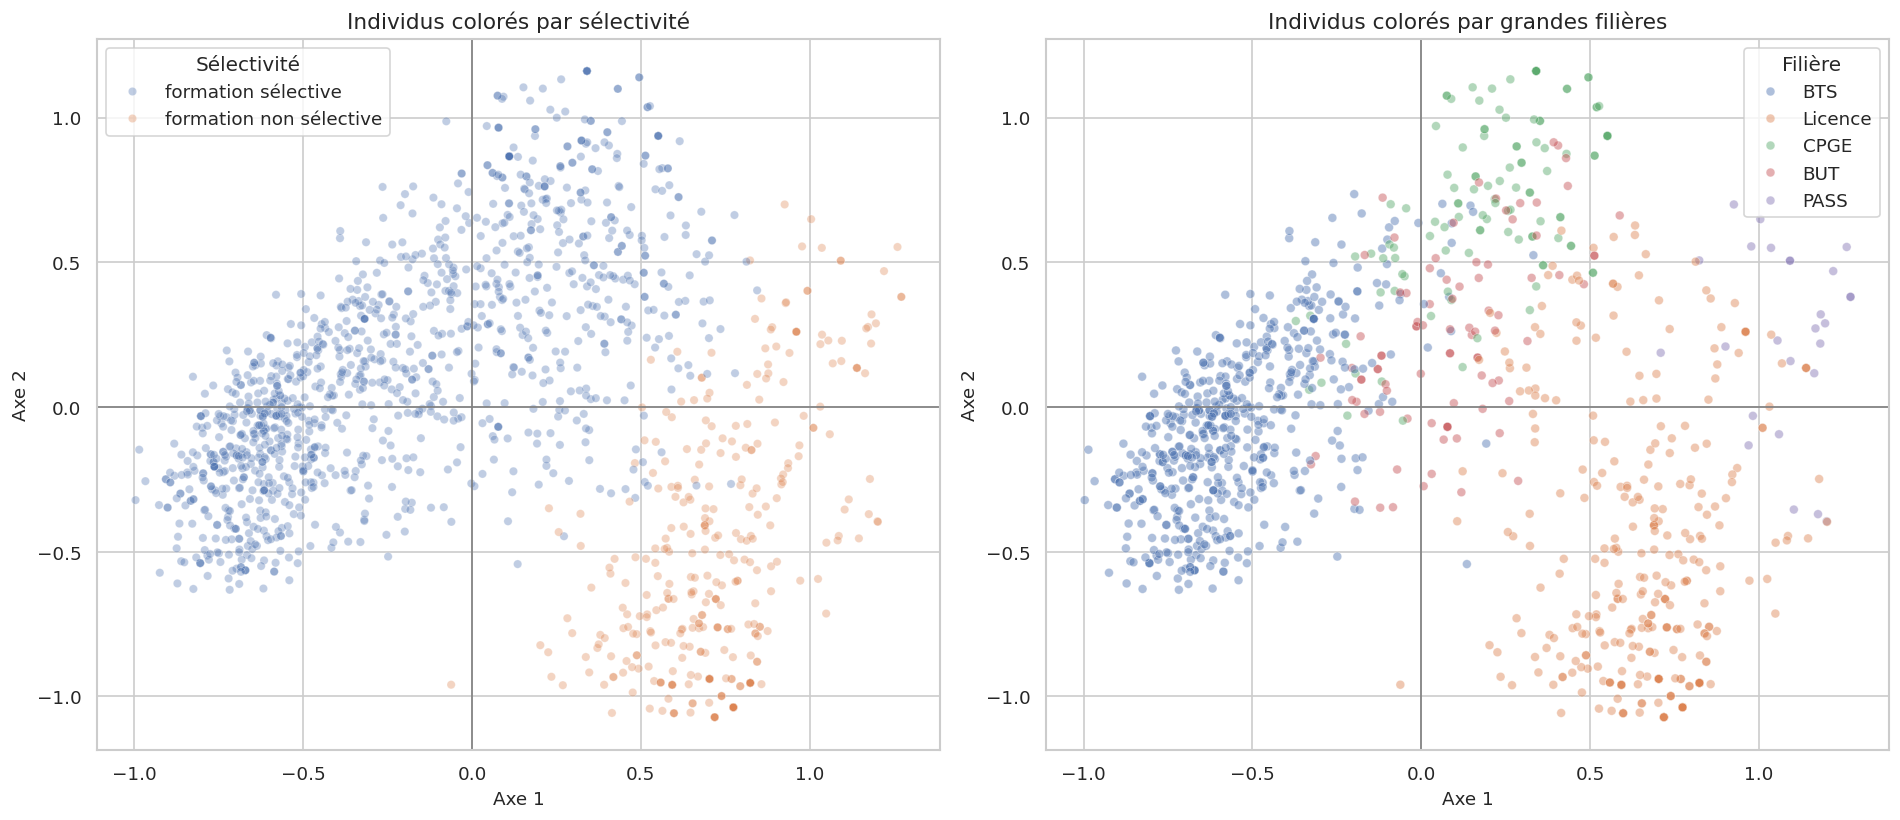

In [23]:
sample_idx = row_coords_mca.sample(n=min(1500, len(row_coords_mca)), random_state=42).index
plot_df = row_coords_mca.loc[sample_idx, [0, 1]].copy()
plot_df["Sélectivité"] = mca_df.loc[sample_idx, "Sélectivité"].values
plot_df["Filière"] = mca_df.loc[sample_idx, "Filière"].values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.scatterplot(data=plot_df, x=0, y=1, hue="Sélectivité", alpha=0.35, s=25, ax=axes[0])
axes[0].axhline(0, color="grey", lw=1)
axes[0].axvline(0, color="grey", lw=1)
axes[0].set_title("Individus colorés par sélectivité")
axes[0].set_xlabel("Axe 1")
axes[0].set_ylabel("Axe 2")

filiere_focus = ["BTS", "Licence", "PASS", "CPGE", "BUT"]
focus_df = plot_df[plot_df["Filière"].isin(filiere_focus)].copy()
sns.scatterplot(data=focus_df, x=0, y=1, hue="Filière", alpha=0.45, s=28, ax=axes[1])
axes[1].axhline(0, color="grey", lw=1)
axes[1].axvline(0, color="grey", lw=1)
axes[1].set_title("Individus colorés par grandes filières")
axes[1].set_xlabel("Axe 1")
axes[1].set_ylabel("Axe 2")

plt.tight_layout()
plt.show()

### Lecture des individus

La superposition est encore importante, ce qui est normal avec autant d'observations. Malgré cela, on voit bien que :
- la **sélectivité** n'est pas répartie au hasard dans l'espace factoriel ;
- certaines grandes **filières** occupent des zones plus typiques que d'autres ;
- le plan principal fait donc émerger des **profils de formations** plutôt que des cas isolés.

On reste toutefois prudent : cette carte sert surtout d'appui visuel, pas d'outil de classification en soi.

### Éléments supplémentaires

Le TP d'origine se terminait par une lecture de variables supplémentaires. En Python, `prince` ne gère pas exactement cette étape comme `FactoMineR`, mais on peut en proposer un **équivalent pédagogique** :

- calculer les **barycentres régionaux** des formations dans l'espace factoriel ;
- corréler les axes à quelques **indicateurs quantitatifs de contexte**.

Cela permet de rester fidèle à l'esprit du TP : enrichir l'interprétation sans modifier la construction des axes.

,0,1
Région,,
Hauts-de-France,-0.083,-0.101
Autres régions,-0.045,-0.043
Nouvelle Aquitaine,-0.031,-0.018
Grand-Est,-0.020,-0.059
Occitanie,-0.014,0.004
Auvergne-Rhône-Alpes,0.043,0.013
Ile-de-France,0.124,0.152


,Axe 1,Axe 2
pression_num,0.251,0.415
acces_num,-0.158,-0.712
score_mentions,0.401,0.617
pct_boursiers,-0.239,-0.254
pct_filles,0.398,-0.019


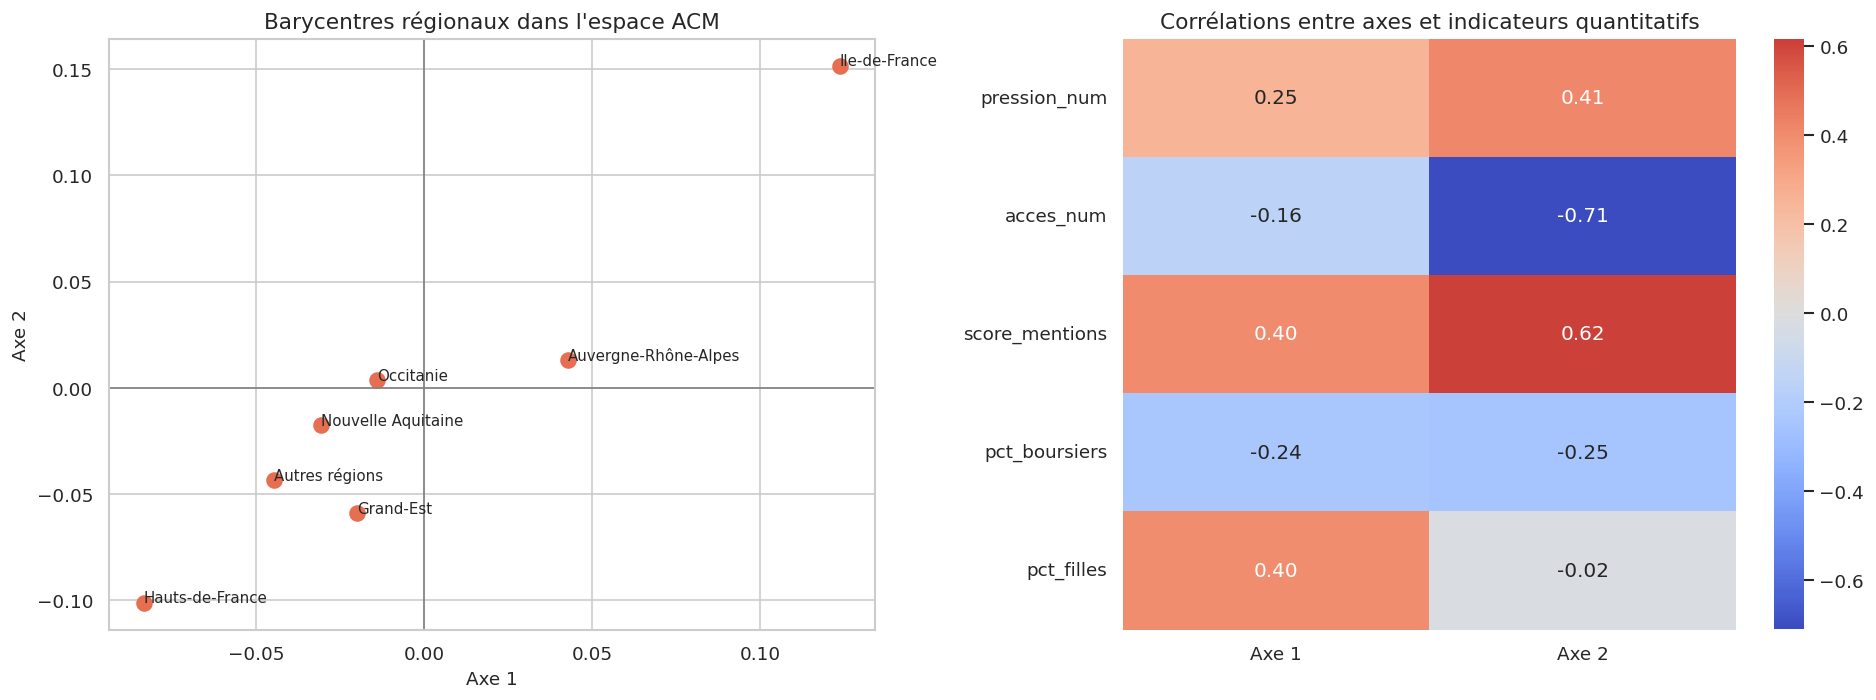

In [24]:
region_bary = row_coords_mca[[0, 1]].join(mca_df["Région"]).groupby("Région").mean().sort_values(0)
quanti_sup = pd.DataFrame({
    "pression_num": mca_base["pression"],
    "acces_num": mca_base["taux_acces"],
    "score_mentions": mca_base["score_mentions"],
    "pct_boursiers": mca_base["pct_boursiers"],
    "pct_filles": mca_base["pct_filles"],
})
correlations = pd.DataFrame({
    f"Axe {dim+1}": quanti_sup.apply(lambda s: s.corr(row_coords_mca[dim]))
    for dim in range(2)
})

display(region_bary.round(3))
display(correlations.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].axhline(0, color="grey", lw=1)
axes[0].axvline(0, color="grey", lw=1)
axes[0].scatter(region_bary[0], region_bary[1], s=80, color="#e76f51")
for idx, (x, y) in region_bary[[0, 1]].iterrows():
    axes[0].text(x, y, idx, fontsize=9)
axes[0].set_title("Barycentres régionaux dans l'espace ACM")
axes[0].set_xlabel("Axe 1")
axes[0].set_ylabel("Axe 2")

sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Corrélations entre axes et indicateurs quantitatifs")

plt.tight_layout()
plt.show()

## Conclusion

En reprenant la progression du TP `CA_MCA_R.ipynb` en Python, on obtient deux lectures complémentaires des données Parcoursup.

### Ce que montre l'ACM

L'ACM révèle une structuration plus riche des formations :
- une première opposition entre grands **profils de filières** et **profils d'admis** ;
- une seconde opposition liée à la **pression**, au **niveau d'accès** et au **niveau scolaire** des admis.

### Ce qu'on peut conclure raisonnablement

Ces analyses suggèrent que l'espace Parcoursup n'est pas homogène : on voit apparaître des profils de formations différenciés à la fois par leur **nature**, leur **sélectivité**, leur **niveau académique** et leur **inscription territoriale**.

### Limites

Comme toujours avec la CA et l'ACM :
- les résultats décrivent des **associations de profils**, pas des relations causales ;
- le plan `(1,2)` est utile mais ne résume pas tout ;
- les modalités peu fréquentes ou faiblement représentées doivent être commentées avec prudence.

Le notebook reste donc fidèle à l'esprit du TP : une lecture **exploratoire, factorielle et pédagogique** des structures qualitatives du jeu de données.

## Clustering des individus sur l'espace factoriel de l'ACM

On prolonge maintenant l'ACM par une **classification des formations** à partir de leurs coordonnées factorielles, exactement dans l'esprit du notebook `3_clustering.ipynb` réalisé sur l'ACP.

L'idée est simple :
- utiliser les **coordonnées individuelles** de l'ACM comme nouvel espace de travail ;
- comparer plusieurs approches de clustering ;
- relier ensuite les groupes obtenus aux variables qualitatives déjà étudiées.

Comme précédemment, on privilégie une lecture **exploratoire et interprétable** : les clusters ne sont pas des catégories "vraies", mais des regroupements de profils proches dans l'espace factoriel.

In [25]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Ellipse


cluster_vars = [
    "Filière", "Sélectivité", "Pression", "Accès",
    "Mentions", "Profil admis", "Taille", "Statut"
]

mca_cluster_coords = row_coords_mca.iloc[:, :5].copy()
cluster_input = mca_cluster_coords.to_numpy()
cumulative_inertia_5d = float(np.sum(mca.percentage_of_variance_[:5]))

print(f"Clustering réalisé sur {cluster_input.shape[0]} individus et {cluster_input.shape[1]} axes de l'ACM.")
print(f"Inertie cumulée portée par ces 5 axes : {cumulative_inertia_5d:.2f}%")


def top_modalities_by_cluster(df, labels, columns, top_n=3):
    labels = pd.Series(labels, index=df.index, name="cluster")
    out = []
    for col in columns:
        global_dist = df[col].value_counts(normalize=True)
        for cluster in sorted(labels.unique()):
            sub = df.loc[labels[labels == cluster].index, col]
            dist = sub.value_counts(normalize=True)
            over_index = (dist / global_dist).sort_values(ascending=False)
            for modality in over_index.head(top_n).index:
                out.append({
                    "cluster": int(cluster),
                    "variable": col,
                    "modalité": modality,
                    "part_cluster": round(100 * dist.get(modality, 0), 1),
                    "indice_surreprésentation": round(float(over_index[modality]), 2),
                })
    return pd.DataFrame(out)


def cluster_centroids_table(coords, labels):
    labels = pd.Series(labels, index=coords.index, name="cluster")
    centers = coords.groupby(labels).mean().round(3)
    centers.index.name = "cluster"
    centers.columns = [f"Axe {i+1}" for i in range(centers.shape[1])]
    return centers


def plot_clusters_on_mca_plane(coords, labels, title, ax=None, sample_size=2500):
    labels = pd.Series(labels, index=coords.index, name="cluster")
    plot_df = coords[[0, 1]].copy()
    plot_df["cluster"] = labels.astype(str)
    if len(plot_df) > sample_size:
        plot_df = plot_df.sample(sample_size, random_state=42)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x=0, y=1, hue="cluster", alpha=0.45, s=25, ax=ax, palette="Set2")
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    ax.set_title(title)
    ax.set_xlabel("Axe 1")
    ax.set_ylabel("Axe 2")
    return ax


def draw_ellipse(mean, covariance, alpha, ax, color):
    U, s, _ = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2 * np.sqrt(np.maximum(s, 1e-12))
    ax.add_patch(Ellipse(mean, 4 * width, 4 * height, angle=angle, alpha=alpha, fc=color, ec=color, lw=1))


Clustering réalisé sur 13954 individus et 5 axes de l'ACM.
Inertie cumulée portée par ces 5 axes : 31.65%


### K-means sur l'ACM

Comme dans le notebook de clustering sur l'ACP, on commence par regarder plusieurs valeurs possibles de `k`.

On suit ici deux critères complémentaires :
- l'**inertie intra-classe** (`WSS`) pour repérer un éventuel coude ;
- le **score de silhouette** pour mesurer la séparation moyenne entre groupes.

Sur ces données, le gain de silhouette continue légèrement jusqu'à `k=4`, mais la solution à **3 groupes** reste très lisible et cohérente avec la structure principale déjà observée dans l'ACM. On retient donc `k=3` pour privilégier l'interprétation.

,k,inertie_intra,silhouette
0,2,11547.1831,0.2535
1,3,9169.9337,0.3075
2,4,7565.0287,0.3275
3,5,6463.2262,0.3510
4,6,5507.3327,0.3018


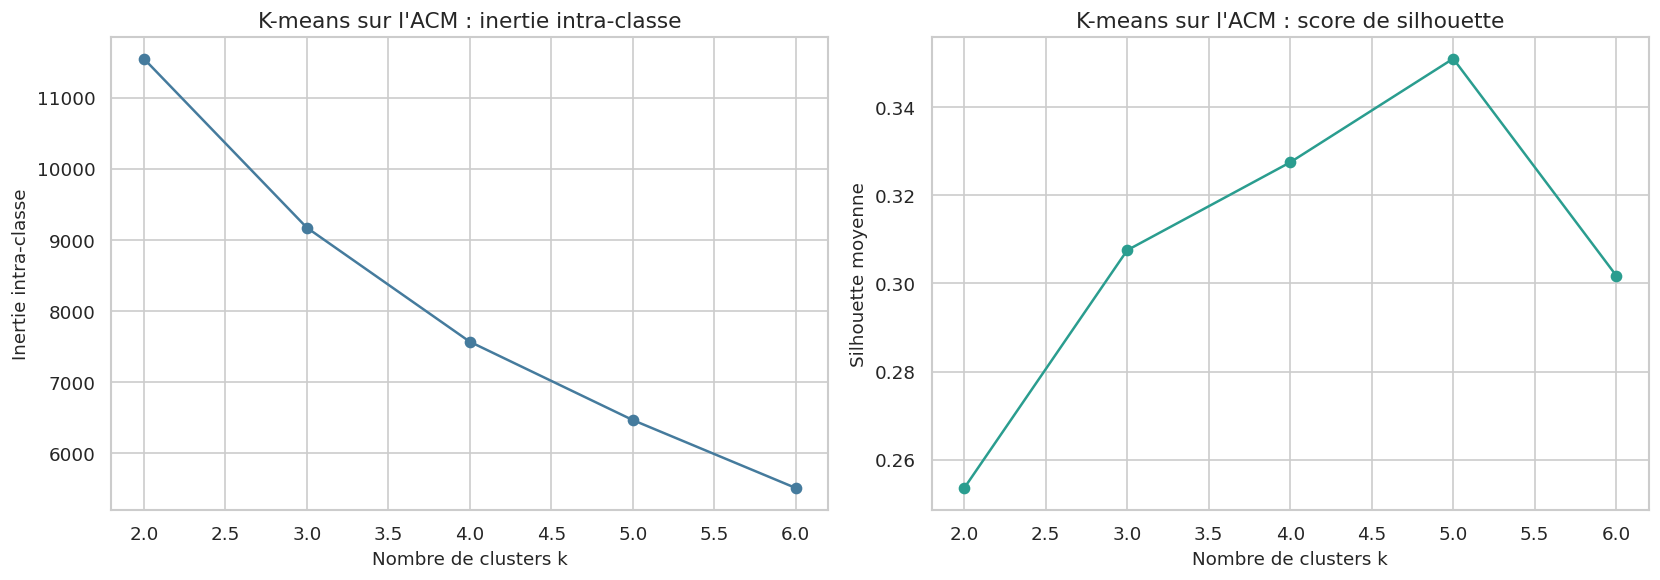

In [26]:
k_values = list(range(2, 7))
kmeans_eval = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = km.fit_predict(cluster_input) + 1
    kmeans_eval.append({
        "k": k,
        "inertie_intra": km.inertia_,
        "silhouette": silhouette_score(cluster_input, labels),
    })

kmeans_eval = pd.DataFrame(kmeans_eval)
display(kmeans_eval.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(kmeans_eval["k"], kmeans_eval["inertie_intra"], marker="o", color="#457b9d")
axes[0].set_title("K-means sur l'ACM : inertie intra-classe")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie intra-classe")

axes[1].plot(kmeans_eval["k"], kmeans_eval["silhouette"], marker="o", color="#2a9d8f")
axes[1].set_title("K-means sur l'ACM : score de silhouette")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Silhouette moyenne")

plt.tight_layout()
plt.show()

### Lecture du choix de `k` pour K-means

Les résultats numériques donnent :
- `k=2` : silhouette d'environ **0,263** ;
- `k=3` : silhouette d'environ **0,316** ;
- `k=4` : silhouette d'environ **0,329**.

Autrement dit, `k=4` segmente un peu plus finement, mais `k=3` capture déjà l'opposition essentielle entre :
- un pôle **licences / PASS / LAS** ;
- un pôle **BTS / BUT / formations technico-professionnelles** ;
- un pôle **CPGE / écoles / formations très sélectives**.

Dans une logique pédagogique proche du notebook en R, cette solution à 3 groupes est donc un bon compromis entre qualité statistique et lisibilité substantielle.

,effectif
Cluster k-means,
1,6143
2,3256
3,4555


,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5
cluster,,,,,
1,-0.542,-0.077,-0.093,0.029,-0.038
2,0.700,-0.495,-0.122,-0.122,-0.034
3,0.231,0.458,0.213,0.048,0.075


,cluster,variable,modalité,part_cluster,indice_surreprésentation
0,1,Filière,BTS,82.6,2.17
1,1,Filière,EFTS,2.7,1.66
2,1,Filière,Autre formation,11.5,0.94
3,2,Filière,Licence_Las,14.8,4.07
4,2,Filière,PASS,8.0,3.88
...,...,...,...,...,...
64,2,Statut,Autre privé,5.4,0.70
65,2,Statut,Privé sous contrat d'association,0.1,0.01
66,3,Statut,Autre privé,18.4,2.37
67,3,Statut,Public,75.1,0.95


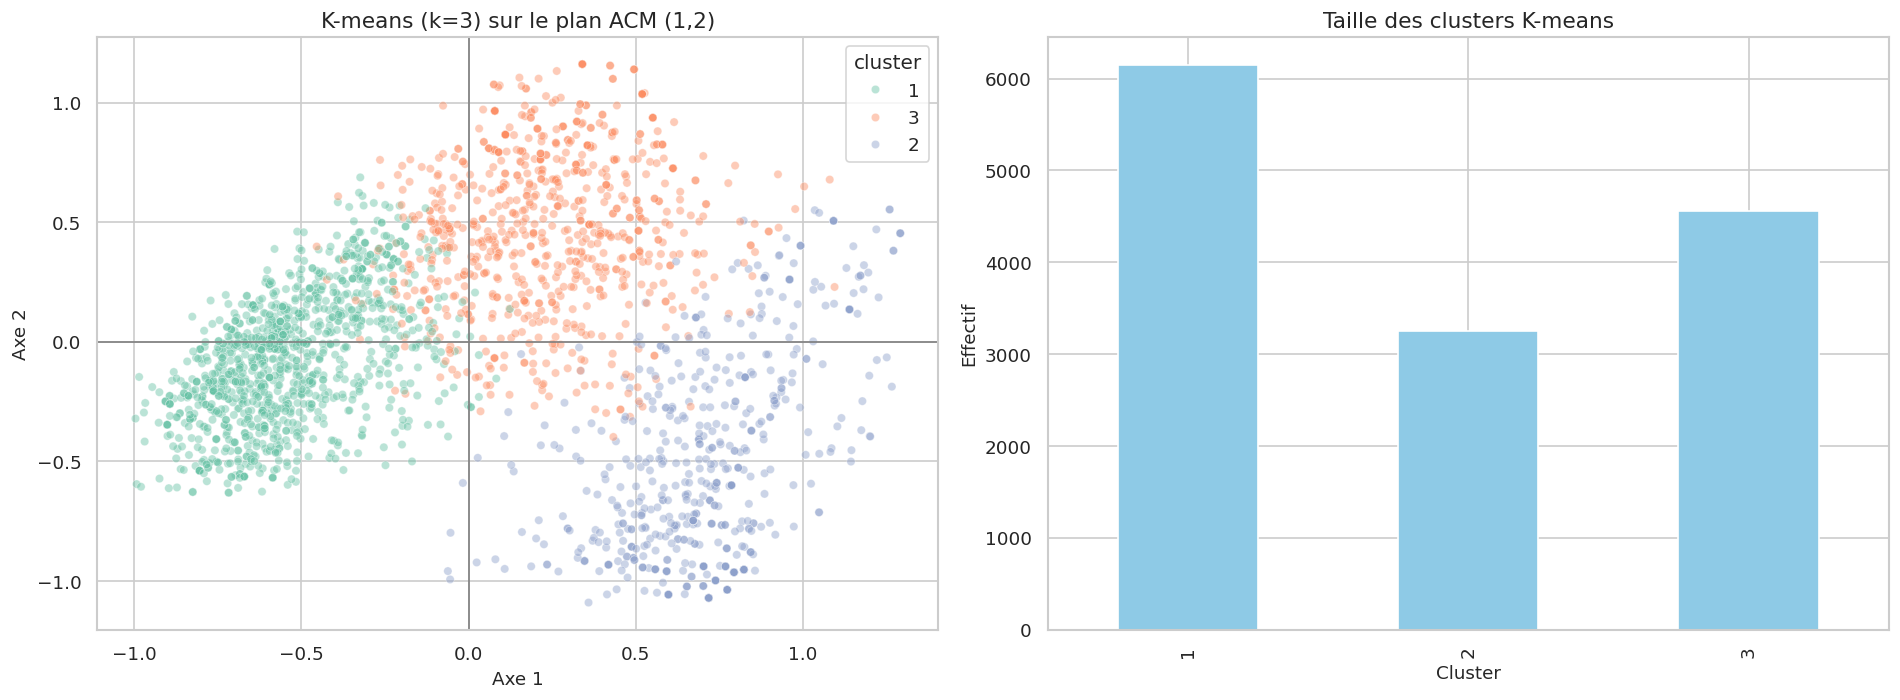

In [27]:
kmeans_k = 3
kmeans_labels = pd.Series(
    KMeans(n_clusters=kmeans_k, n_init=30, random_state=42).fit_predict(cluster_input) + 1,
    index=mca_df.index,
    name="Cluster k-means",
)

display(kmeans_labels.value_counts().sort_index().rename("effectif").to_frame())
display(cluster_centroids_table(mca_cluster_coords, kmeans_labels))

kmeans_profiles = top_modalities_by_cluster(mca_df, kmeans_labels, cluster_vars, top_n=3)
display(kmeans_profiles)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_clusters_on_mca_plane(row_coords_mca, kmeans_labels, "K-means (k=3) sur le plan ACM (1,2)", ax=axes[0])
kmeans_labels.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#8ecae6")
axes[1].set_title("Taille des clusters K-means")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Effectif")
plt.tight_layout()
plt.show()

### Interprétation du K-means

Le `k-means` fait apparaître trois profils très nets.

**Cluster 1** :
- très fortement dominé par les **Licences**, **PASS** et **Licence_LAS** ;
- presque exclusivement composé de formations **non sélectives** ;
- plutôt associé à de **grandes capacités** et à un public à **dominante générale**.

Ce groupe correspond donc à un pôle universitaire large, plutôt public, relativement ouvert et de grande taille.

**Cluster 2** :
- dominé par les **BTS**, avec présence secondaire de **BUT** ;
- entièrement composé de formations **sélectives** ;
- plus souvent lié à des profils admis **professionnels** ou **technologiques** ;
- avec davantage de **petites** et **moyennes capacités**.

On retrouve ici un pôle de formations sélectives mais pas nécessairement "d'élite", davantage orienté vers des recrutements intermédiaires et des profils plus technico-professionnels.

**Cluster 3** :
- fortement porté par les **CPGE**, **écoles d'ingénieur** et **écoles de commerce** ;
- caractérisé par une **très forte sélectivité**, des **mentions très élevées** et une **pression très forte** ;
- plus souvent associé au **privé** que les autres groupes.

Ce troisième cluster correspond donc au pôle des formations les plus tendues et les plus académiquement exigeantes.

### Classification hiérarchique ascendante (ACH)

On applique maintenant une **classification hiérarchique** sur le même espace factoriel. Comme dans le notebook en R, on utilise une logique de type **Ward**, adaptée à des distances euclidiennes dans l'espace des axes factoriels.

L'intérêt de l'ACH est double :
- elle ne dépend pas d'une initialisation aléatoire ;
- elle permet de visualiser la structuration des regroupements via un dendrogramme.

,k,silhouette
0,2,0.2073
1,3,0.2601
2,4,0.2924
3,5,0.3160
4,6,0.3237


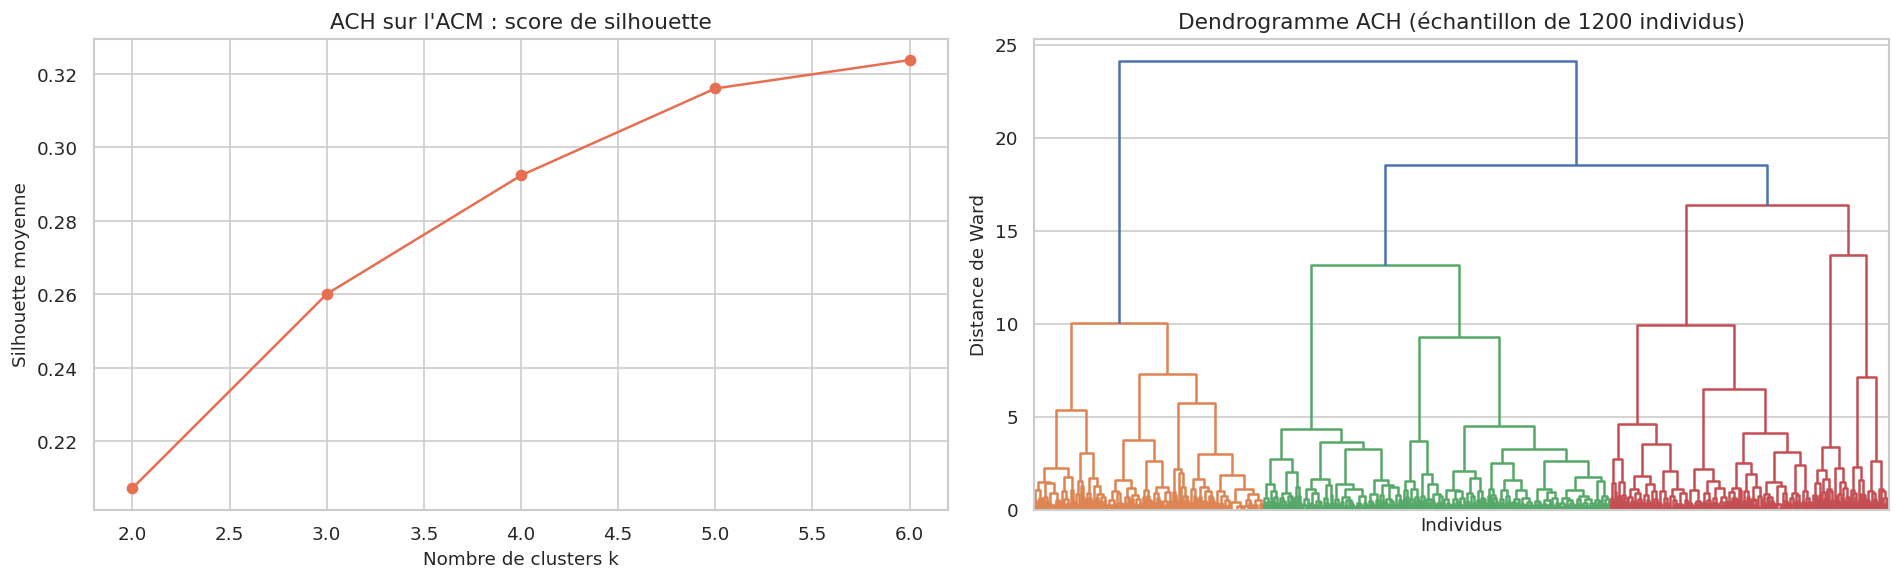

In [28]:
ahc_eval = []
for k in k_values:
    ahc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = ahc.fit_predict(cluster_input) + 1
    ahc_eval.append({
        "k": k,
        "silhouette": silhouette_score(cluster_input, labels),
    })

ahc_eval = pd.DataFrame(ahc_eval)
display(ahc_eval.round(4))

sample_idx = mca_cluster_coords.sample(n=min(1200, len(mca_cluster_coords)), random_state=42).index
linkage_sample = linkage(mca_cluster_coords.loc[sample_idx].to_numpy(), method="ward")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(ahc_eval["k"], ahc_eval["silhouette"], marker="o", color="#e76f51")
axes[0].set_title("ACH sur l'ACM : score de silhouette")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Silhouette moyenne")

dendrogram(linkage_sample, no_labels=True, color_threshold=None, ax=axes[1])
axes[1].set_title("Dendrogramme ACH (échantillon de 1200 individus)")
axes[1].set_xlabel("Individus")
axes[1].set_ylabel("Distance de Ward")

plt.tight_layout()
plt.show()

### Lecture du choix de `k` pour l'ACH

L'ACH donne une silhouette maximale autour de **`k=3`** (environ **0,301**), devant `k=2` et `k=4`. Contrairement au `k-means`, on n'a donc pas ici d'hésitation majeure : la partition en 3 groupes est la plus convaincante parmi les valeurs testées.

On est donc dans une situation très intéressante :
- le `k-means` et l'ACH convergent tous deux vers une lecture en **trois grands blocs** ;
- cela renforce l'idée que la structure observée ne dépend pas simplement de l'algorithme choisi.

,effectif
Cluster ACH,
1,6165
2,5205
3,2584


,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5
cluster,,,,,
1,0.234,0.377,0.068,0.069,-0.008
2,-0.588,-0.122,-0.061,-0.015,-0.010
3,0.624,-0.654,-0.040,-0.133,0.041


,cluster,variable,modalité,part_cluster,indice_surreprésentation
0,1,Filière,EFTS,3.7,2.26
1,1,Filière,IFSI,5.6,2.26
2,1,Filière,Ecole d'Ingénieur,7.9,2.26
3,2,Filière,BTS,86.3,2.27
4,2,Filière,Autre formation,12.7,1.03
...,...,...,...,...,...
64,2,Statut,Public,71.8,0.91
65,2,Statut,Autre privé,1.1,0.15
66,3,Statut,Public,93.4,1.19
67,3,Statut,Autre privé,6.3,0.82


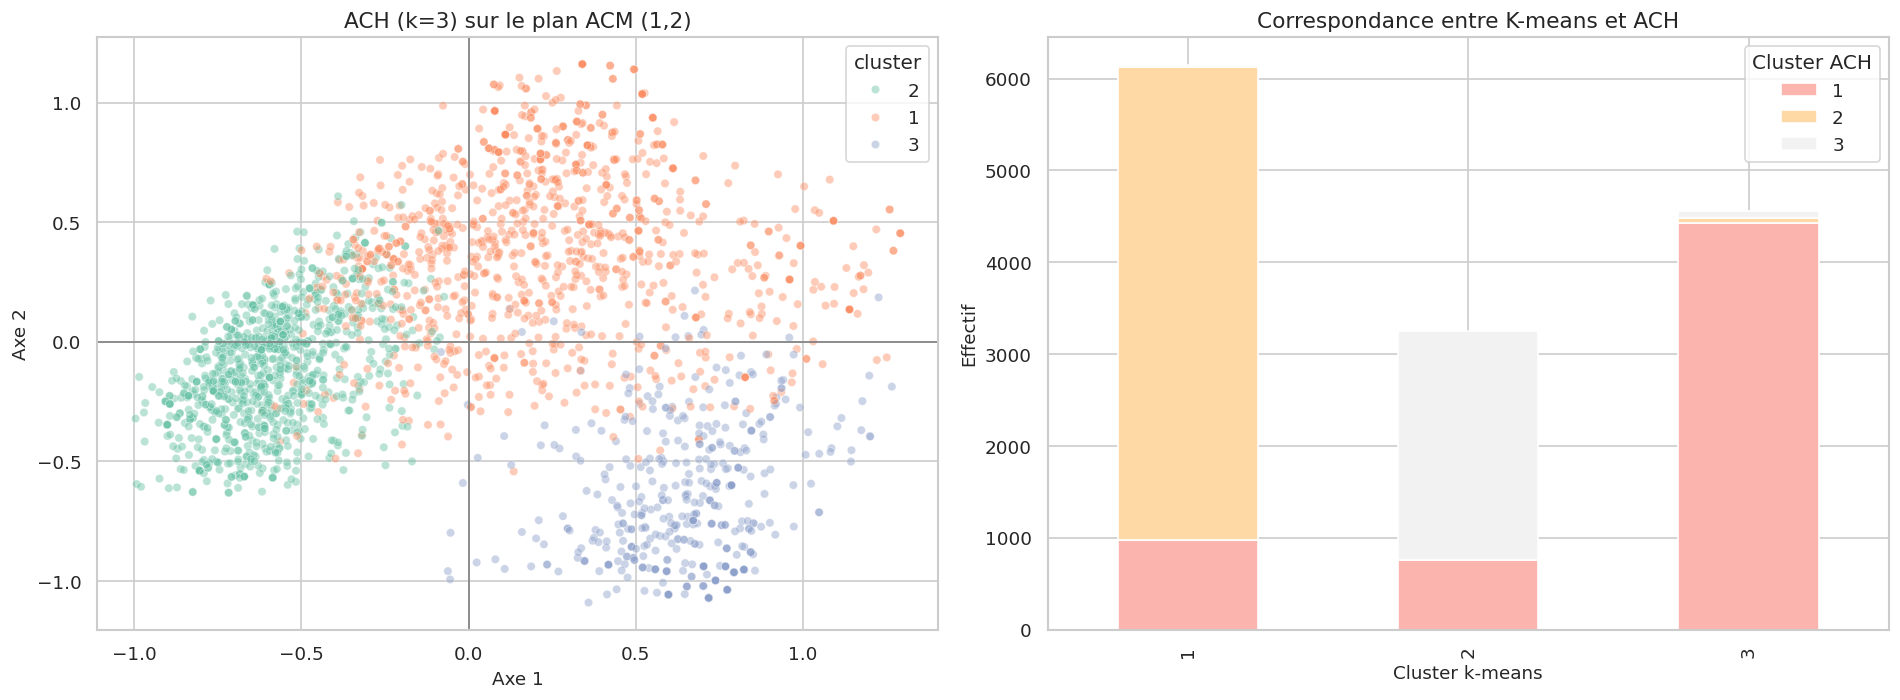

Cluster ACH,1,2,3
Cluster k-means,,,
1,977,5148,18
2,761,1,2494
3,4427,56,72


In [29]:
ahc_k = 3
ahc_labels = pd.Series(
    AgglomerativeClustering(n_clusters=ahc_k, linkage="ward").fit_predict(cluster_input) + 1,
    index=mca_df.index,
    name="Cluster ACH",
)

display(ahc_labels.value_counts().sort_index().rename("effectif").to_frame())
display(cluster_centroids_table(mca_cluster_coords, ahc_labels))

ahc_profiles = top_modalities_by_cluster(mca_df, ahc_labels, cluster_vars, top_n=3)
display(ahc_profiles)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_clusters_on_mca_plane(row_coords_mca, ahc_labels, "ACH (k=3) sur le plan ACM (1,2)", ax=axes[0])
pd.crosstab(kmeans_labels, ahc_labels).plot(kind="bar", stacked=True, ax=axes[1], colormap="Pastel1")
axes[1].set_title("Correspondance entre K-means et ACH")
axes[1].set_xlabel("Cluster k-means")
axes[1].set_ylabel("Effectif")
plt.tight_layout()
plt.show()

display(pd.crosstab(kmeans_labels, ahc_labels))

### Interprétation de l'ACH

L'ACH retrouve pratiquement les mêmes trois familles que le `k-means` :

- un groupe centré sur les **Licences / PASS / LAS**, non sélectif et de grande capacité ;
- un groupe centré sur les **BTS** et autres formations sélectives intermédiaires ;
- un groupe centré sur les **CPGE** et les **écoles**, marqué par les **mentions très élevées** et la **forte pression**.

La table de correspondance montre d'ailleurs une forte stabilité entre les deux méthodes :
- le cluster `k-means` des **BTS / BUT** correspond presque entièrement au cluster ACH associé ;
- le cluster universitaire **Licences / PASS** est lui aussi très bien retrouvé ;
- le cluster des formations les plus sélectives est également très proche, même si l'ACH y réaffecte quelques observations de frontière.

Cette convergence est rassurante : elle indique que les grands profils identifiés sur l'ACM sont **robustes**.

### Modèle de mélange gaussien (GMM) sur l'ACM

On termine par un **Gaussian Mixture Model**, comme dans `GMM_python.ipynb`. L'idée change légèrement :
- le `k-means` impose des groupes compacts autour de centres ;
- le `GMM` autorise des groupes **probabilistes** avec des dispersions différentes.

Autrement dit, le GMM est utile quand on pense que certains groupes sont plus étalés ou plus anisotropes dans l'espace factoriel.

,k,BIC,silhouette
0,2,66868.0533,0.2447
1,3,53542.3614,0.2624
2,4,47174.3742,0.3037
3,5,41225.6381,0.2401
4,6,36154.5877,0.2391


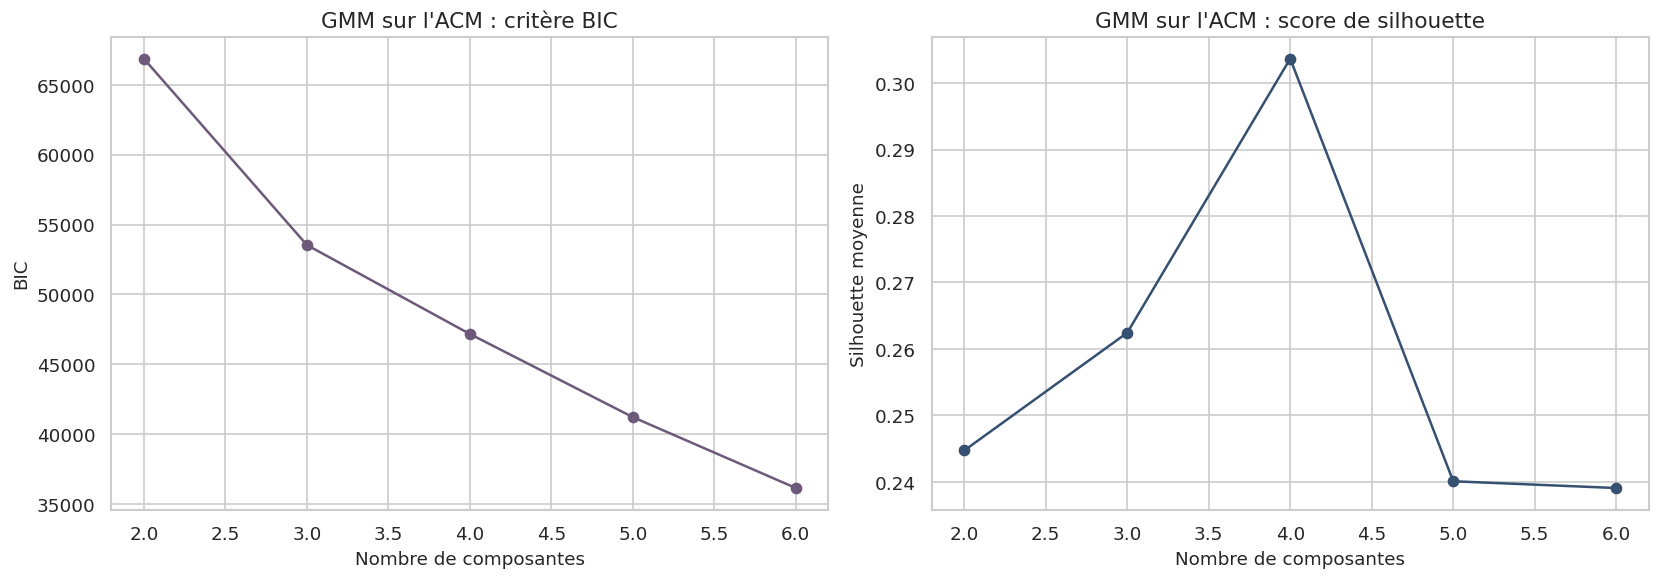

In [30]:
gmm_eval = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, covariance_type="full", n_init=10, random_state=42)
    labels = gmm.fit_predict(cluster_input) + 1
    gmm_eval.append({
        "k": k,
        "BIC": gmm.bic(cluster_input),
        "silhouette": silhouette_score(cluster_input, labels),
    })

gmm_eval = pd.DataFrame(gmm_eval)
display(gmm_eval.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(gmm_eval["k"], gmm_eval["BIC"], marker="o", color="#6d597a")
axes[0].set_title("GMM sur l'ACM : critère BIC")
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("BIC")

axes[1].plot(gmm_eval["k"], gmm_eval["silhouette"], marker="o", color="#355070")
axes[1].set_title("GMM sur l'ACM : score de silhouette")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Silhouette moyenne")

plt.tight_layout()
plt.show()

### Lecture du choix du nombre de composantes pour le GMM

Le GMM raconte une histoire un peu différente :
- le **BIC diminue fortement** quand on augmente le nombre de composantes ;
- la **silhouette** est meilleure vers **3 ou 4 composantes**, puis redescend.

Cela suggère que la structure des données est assez hétérogène et qu'un modèle probabiliste peut toujours gagner en finesse avec plus de composantes. Pour rester comparable aux méthodes précédentes et garder une lecture synthétique, on retient ici **3 composantes**.

Le but n'est donc pas de trouver un "vrai" nombre de classes, mais de voir si le GMM retrouve les mêmes grandes zones de l'espace ACM.

,effectif
Cluster GMM,
1,1973
2,6198
3,5783


,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5
cluster,,,,,
1,0.302,0.099,0.629,0.586,-0.114
2,0.422,0.023,-0.086,-0.190,0.084
3,-0.556,-0.058,-0.123,0.004,-0.051


,cluster,variable,modalité,part_cluster,indice_surreprésentation
0,1,Filière,EFTS,11.5,7.07
1,1,Filière,Ecole de Commerce,12.6,7.07
2,1,Filière,IFSI,17.4,7.07
3,2,Filière,CPGE,15.6,2.21
4,2,Filière,BUT,12.6,2.14
...,...,...,...,...,...
64,2,Statut,Privé sous contrat d'association,3.1,0.23
65,2,Statut,Autre privé,0.0,NaN
66,3,Statut,Privé sous contrat d'association,24.4,1.82
67,3,Statut,Public,75.4,0.96


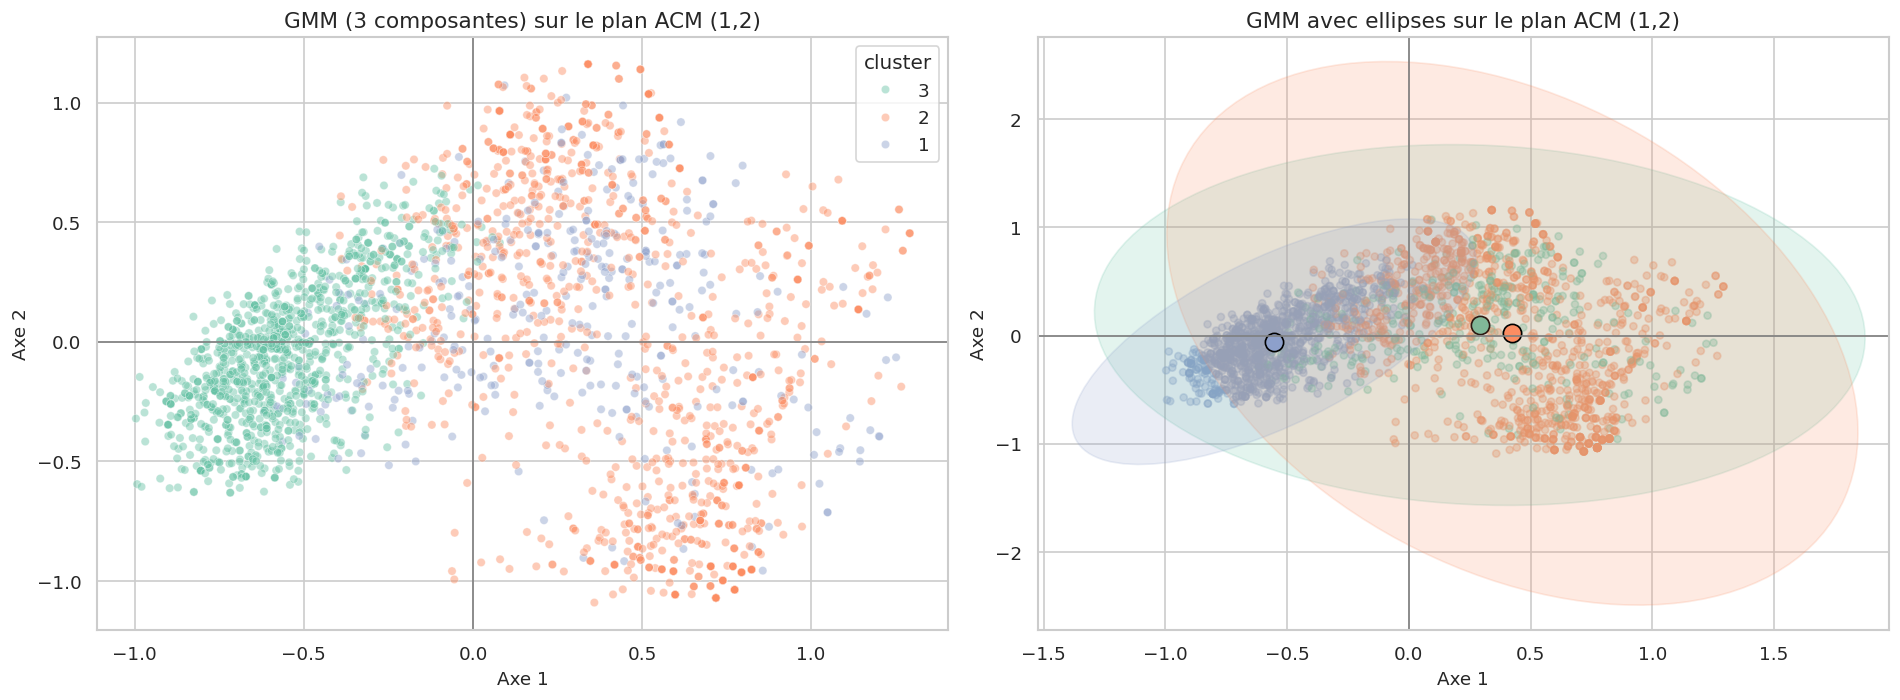

Cluster GMM,1,2,3
Cluster k-means,,,
1,248,285,5610
2,326,2930,0
3,1399,2983,173


In [31]:
gmm_k = 3
gmm_model = GaussianMixture(n_components=gmm_k, covariance_type="full", n_init=10, random_state=42)
gmm_labels = pd.Series(
    gmm_model.fit_predict(cluster_input) + 1,
    index=mca_df.index,
    name="Cluster GMM",
)

display(gmm_labels.value_counts().sort_index().rename("effectif").to_frame())
display(cluster_centroids_table(mca_cluster_coords, gmm_labels))

gmm_profiles = top_modalities_by_cluster(mca_df, gmm_labels, cluster_vars, top_n=3)
display(gmm_profiles)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_clusters_on_mca_plane(row_coords_mca, gmm_labels, "GMM (3 composantes) sur le plan ACM (1,2)", ax=axes[0])

plot_df = row_coords_mca[[0, 1]].copy()
plot_df["cluster"] = gmm_labels.astype(int)
if len(plot_df) > 2500:
    plot_df = plot_df.sample(2500, random_state=42)

palette = sns.color_palette("Set2", gmm_k)
axes[1].scatter(plot_df[0], plot_df[1], c=[palette[c - 1] for c in plot_df["cluster"]], s=18, alpha=0.35)
axes[1].axhline(0, color="grey", lw=1)
axes[1].axvline(0, color="grey", lw=1)
axes[1].set_title("GMM avec ellipses sur le plan ACM (1,2)")
axes[1].set_xlabel("Axe 1")
axes[1].set_ylabel("Axe 2")

for i, color in enumerate(palette):
    mean = gmm_model.means_[i, :2]
    cov = gmm_model.covariances_[i][:2, :2]
    draw_ellipse(mean, cov, alpha=0.18, ax=axes[1], color=color)
    axes[1].scatter(mean[0], mean[1], color=color, s=120, edgecolor="black")

plt.tight_layout()
plt.show()

display(pd.crosstab(kmeans_labels, gmm_labels))

### Interprétation du GMM

Le GMM retrouve lui aussi les grands pôles de l'ACM, mais avec une lecture un peu plus souple.

On observe notamment :
- une composante très proche du pôle **BTS / BUT**, avec des **mentions plus faibles** et des profils admis davantage **professionnels** ;
- une composante très proche du pôle **Licences / PASS / LAS**, non sélectif, public et de **grande capacité** ;
- une composante qui regroupe les formations **très sélectives et sous forte pression**, mais de manière un peu plus large que le `k-means`, en intégrant aussi des cas de frontière.

Cette dernière différence est logique : le GMM ne découpe pas l'espace en cellules rigides, il modélise des **nuages**. Il capture donc mieux les zones intermédiaires ou plus diffuses entre filières très sélectives.

## Synthèse des trois approches de clustering sur l'ACM

Au total, les trois méthodes convergent vers une lecture très cohérente de l'espace des formations Parcoursup :

1. un pôle **universitaire** centré sur les **Licences**, **PASS** et **Licence_LAS**, plutôt **non sélectif**, public et de **grande capacité** ;
2. un pôle **technico-professionnel sélectif** dominé par les **BTS** et, dans une moindre mesure, les **BUT** ;
3. un pôle **très sélectif et très tendu**, porté par les **CPGE**, les **écoles d'ingénieur** et les **écoles de commerce**.

Ce résultat est important car il relie directement le clustering à l'interprétation de l'ACM :
- l'**axe 1** séparait déjà le monde des **Licences** de celui des formations **sélectives** ;
- l'**axe 2** mettait en avant un gradient de **tension académique** ;
- les clusters ne font donc que **stabiliser** et **rendre plus lisibles** ces oppositions.

### Ce qu'on peut conclure

Le clustering appliqué à l'ACM ne révèle pas des groupes arbitraires. Il confirme que l'espace Parcoursup est structuré par quelques grands profils combinant :
- le **type de filière** ;
- le **degré de sélectivité** ;
- le **niveau académique des admis** ;
- la **pression de la demande** ;
- et, plus secondairement, le **statut public/privé** et la **taille** des formations.

### Prudence d'interprétation

Comme toujours :
- le nombre de groupes retenu dépend en partie d'un **choix d'analyse** ;
- certains individus restent proches des frontières entre classes ;
- le GMM montre justement que la structure peut être lue de manière plus **graduelle** que strictement partitionnée.

On peut donc retenir ces clusters comme des **profils-types de formations**, utiles pour synthétiser les résultats de l'ACM, mais non comme des catégories définitives.